In [5]:
from pathlib import Path
import pandas as pd
from functools import reduce
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# Crear tablas comparativas

In [6]:
reports_dir = Path("../reports")

files = sorted(reports_dir.glob("*/*_xai_metrics_report_*.csv"))

metric_dfs = []

for metric_dir in sorted({file.parent for file in files}):
    metric_name = metric_dir.name
    metric_files = sorted(metric_dir.glob("*_xai_metrics_report_*.csv"))

    long_parts = []

    for file in metric_files:
        df = pd.read_csv(file)

        if 'observation' not in df.columns:
            continue

        df['dataset_name'] = df['dataset_name'].astype(str)
        df['model_name'] = df['model_name'].astype(str)
        df['observation'] = df['observation'].astype(str)

        id_cols = ['dataset_name', 'model_name', 'observation', 'metric_params']
        xai_cols = [c for c in df.columns if c not in id_cols]

        long_parts.append(
            df.melt(
                id_vars=['dataset_name', 'model_name', 'observation'],
                value_vars=xai_cols,
                var_name="xai_method",
                value_name=metric_name
            )
        )

    if long_parts:
        metric_df = pd.concat(long_parts, ignore_index=True)
        metric_df['xai_method'] = metric_df['xai_method'].astype(str)
        metric_dfs.append(metric_df)

if not metric_dfs:
    raise ValueError("No se han encontrado informes por observación.")

analysis_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["dataset_name", "model_name", "observation", "xai_method"],
        how="outer",
    ),
    metric_dfs,
)

Path('results').mkdir(exist_ok=True)
analysis_df.to_csv("results/metric_analysis_matrix.csv", index=False)

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


In [7]:
from pathlib import Path
import pandas as pd

reports_dir = Path("../reports")

files = sorted(reports_dir.glob("xai_metrics_report_*.csv"))

parts = []

for file in files:
    df = pd.read_csv(file)

    id_cols = ["dataset_name", "model_name", "metric", "metric_params"]
    xai_cols = [c for c in df.columns if c not in id_cols]

    long_df = df.melt(
        id_vars=["dataset_name", "model_name", "metric"],
        value_vars=xai_cols,
        var_name="xai_method",
        value_name="value"
    )

    parts.append(long_df)

agg_long = pd.concat(parts, ignore_index=True)

analysis_agg_df = agg_long.pivot_table(
    index=["dataset_name", "model_name", "xai_method"],
    columns="metric",
    values="value",
    aggfunc="mean"
).reset_index()

analysis_agg_df.columns.name = None

id_cols = ["dataset_name", "model_name", "xai_method"]

metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors="coerce")


Path('results').mkdir(exist_ok=True)
analysis_agg_df.to_csv("results/metric_analysis_agg_matrix.csv", index=False)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


# Análisis de métricas por observación

In [85]:
matrix_path = Path("results/metric_analysis_matrix.csv")
analysis_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'observation', 'xai_method']
global_metrics = ['SensitivityN']

metric_categories = {
    "Complexity": "Complexity",
    "Sparseness": "Complexity",
    "Faithfulness": "Faithfulness",
    "FaithfulnessEstimate": "Faithfulness",
    "LocalLipschitzEstimate": "Robustness",
    "AvgSensitivity": "Sensitivity",
    "MaxSensitivity": "Robustness",
    "RelativeInputStability": "Robustness",
    "RelativeOutputStability": "Robustness",
    "NonSensitivity": "Fidelity",
    "Consistency": "Faithfulness",
    "Monotonicity": "Faithfulness",
    "MonotonicityCorrelation": "Faithfulness",
    "MonotonicityMetric": "Faithfulness",
    "Sufficiency": "Faithfulness",
    "SensitivityN": "Faithfulness",
    "Completeness": "Fidelity"
}

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


## Análisis descriptivo de las métricas

In [9]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

summary = analysis_df[metric_cols].describe().T

summary['missing'] = analysis_df[metric_cols].isna().sum()
summary['missing_pct'] = analysis_df[metric_cols].isna().mean() * 100
summary['std'] = analysis_df[metric_cols].std()
summary['range'] = summary['max'] - summary['min']

summary['scope'] = 'individual'
summary.loc[summary.index.isin(global_metrics), 'scope'] = 'global'

summary['interpretation_note'] = ""
summary.loc[
    summary.index.isin(global_metrics),
    'interpretation_note'
] = "Métrica global; no se calcula por observación individual."


summary = summary[
    ['scope', 'mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'interpretation_note']
].sort_values(['scope', 'std'], ascending=False)

summary

,scope,mean,std,min,max,range,missing,missing_pct,interpretation_note
RelativeOutputStability,individual,6.993233e+08,1.915161e+10,9.010076e-01,7.436560e+11,7.436560e+11,1566,47.802198,
MaxSensitivity,individual,2.187273e+02,4.067615e+03,6.196479e-02,1.252843e+05,1.252842e+05,0,0.000000,
RelativeInputStability,individual,2.857256e+02,3.268942e+03,1.346755e-06,1.083559e+05,1.083559e+05,1544,47.130647,
AvgSensitivity,individual,1.560641e+02,2.933460e+03,3.275383e-02,9.097839e+04,9.097836e+04,70,2.136752,
LocalLipschitzEstimate,individual,5.632668e+00,3.851099e+00,1.680686e-01,3.137428e+01,3.120621e+01,0,0.000000,
NonSensitivity,individual,3.348291e+00,2.880500e+00,0.000000e+00,1.400000e+01,1.400000e+01,0,0.000000,
Complexity,individual,1.710416e+00,5.554152e-01,-1.000089e-12,2.754321e+00,2.754321e+00,0,0.000000,
FaithfulnessEstimate,individual,-2.624050e-02,5.150242e-01,-9.999986e-01,9.999970e-01,1.999996e+00,0,0.000000,
Faithfulness,individual,-1.077788e-01,5.011228e-01,-9.999955e-01,9.937259e-01,1.993721e+00,0,0.000000,
Sufficiency,individual,5.374141e-01,4.251430e-01,0.000000e+00,1.000000e+00,1.000000e+00,0,0.000000,


In [10]:
sns.set_theme(style='whitegrid', context='notebook')

summary_plot = summary.copy()

if 'scope' in summary_plot.columns:
    summary_plot = summary_plot[summary_plot['scope'] == 'individual']
else:
    summary_plot = summary_plot.drop(index=global_metrics, errors='ignore')

summary_plot = summary_plot.sort_values('std', ascending=False)

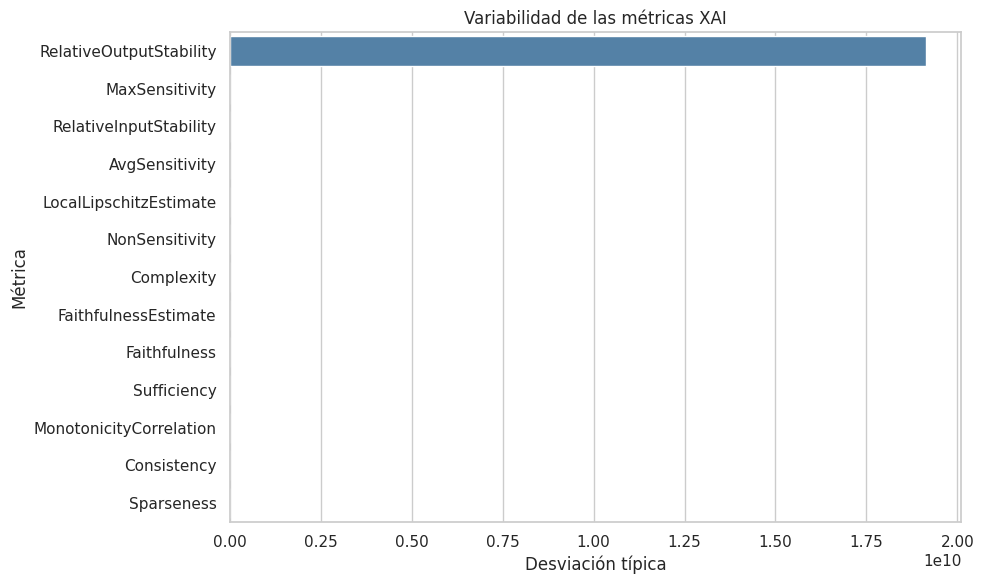

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

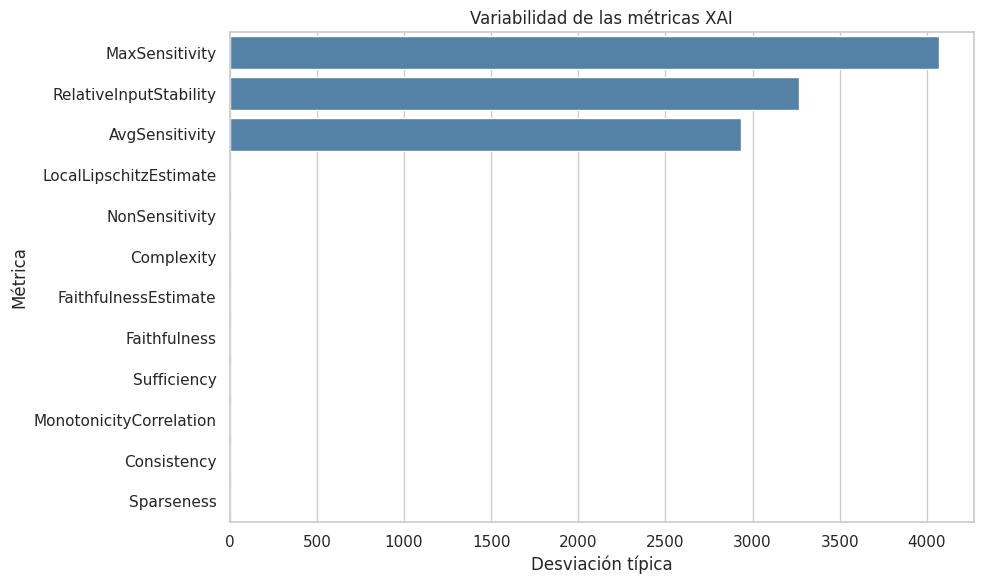

In [12]:
summary_plot_aux = summary_plot.drop(index=['RelativeOutputStability'])
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

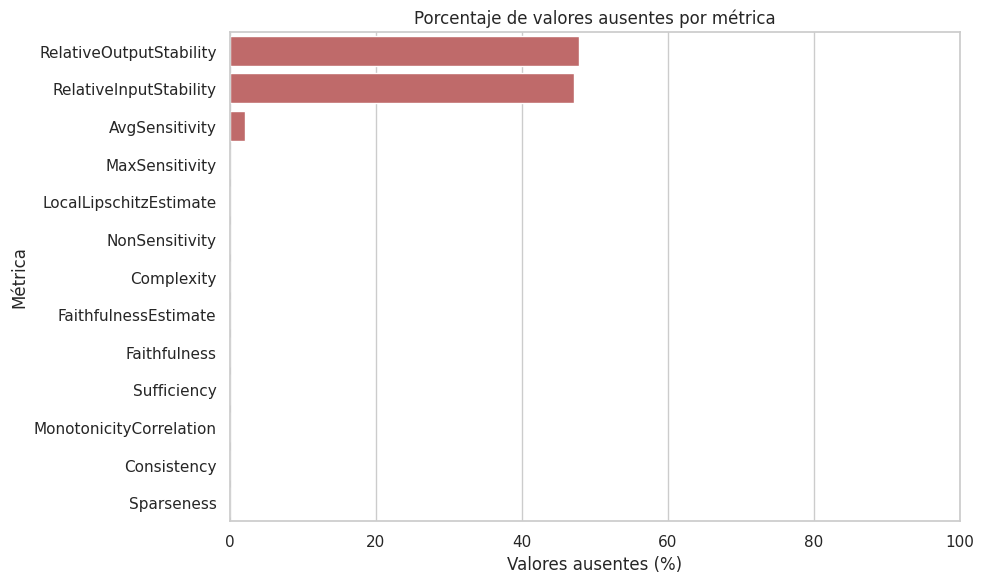

In [13]:
missing_plot = summary_plot.sort_values("missing_pct", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_plot.reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)

plt.title("Porcentaje de valores ausentes por métrica")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

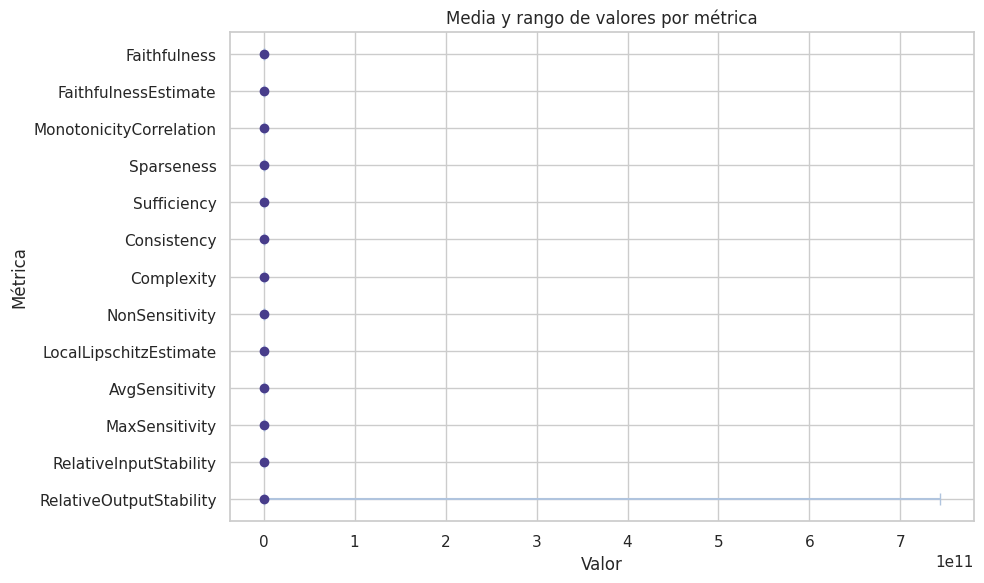

In [14]:
range_plot = summary_plot.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

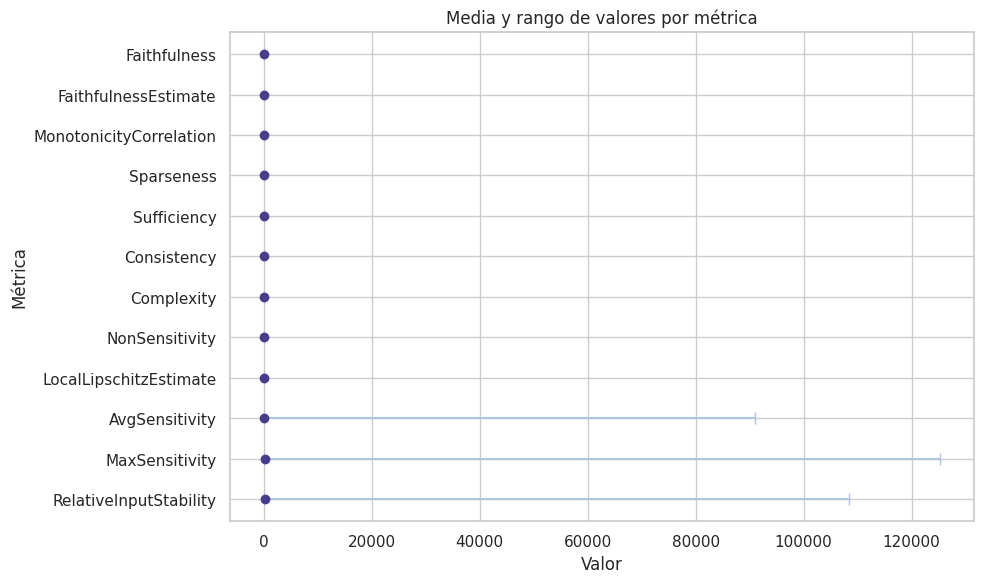

In [15]:
range_plot = summary_plot_aux.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

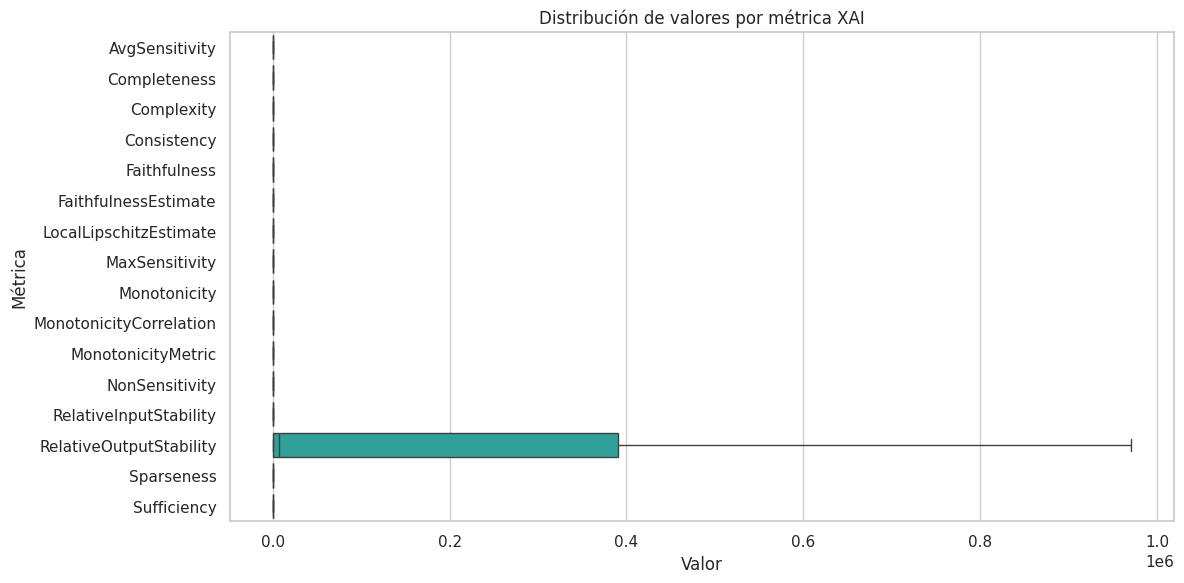

In [16]:
metric_cols_individual = [
    c for c in metric_cols
    if c not in global_metrics
]

plot_df = analysis_df[metric_cols_individual].copy()

for col in metric_cols_individual:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_long = plot_df.melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)

plt.title("Distribución de valores por métrica XAI")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

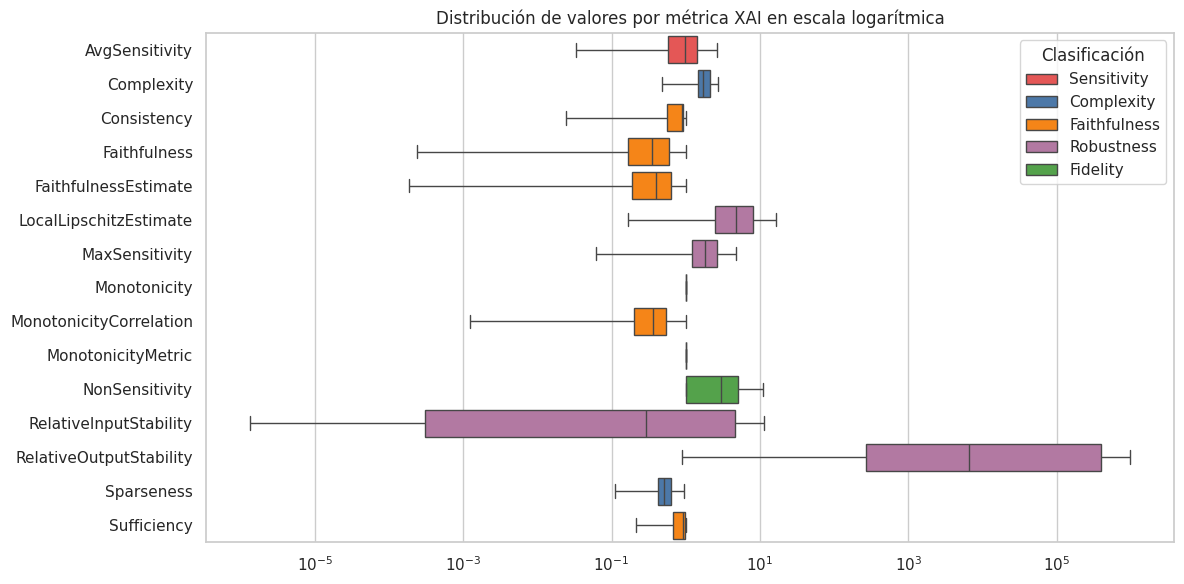

In [100]:
plot_long_positive = plot_long[plot_long["value"] > 0].copy()
plot_long_positive["category"] = plot_long_positive["metric"].map(metric_categories)

plt.figure(figsize=(12, 6))


category_palette = {
    "Complexity": "#4C78A8",
    "Faithfulness": "#F58518",
    "Fidelity": "#54A24B",
    "Robustness": "#B279A2",
    "Sensitivity": "#E45756",
}

sns.boxplot(
    data=plot_long_positive,
    x="value",
    y="metric",
    hue="category",
    palette=category_palette,
    dodge=False,
    showfliers=False,
    saturation=1
)

plt.legend(title="Clasificación")

plt.xscale("log")
plt.title("Distribución de valores por métrica XAI en escala logarítmica")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Correlación entre métricas

In [18]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

X = analysis_df[metric_cols].dropna(axis=0, how='any')

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=metric_cols,
    index=X.index
)

corr = X_scaled.corr(method='spearman')

corr

,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
AvgSensitivity,1.000000,NaN,0.075278,0.280613,-0.224960,-0.077672,0.125863,0.909580,-0.030397,0.037748,-0.109762,0.222744,0.107432,0.360318,0.014856,0.251859
Completeness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity,0.075278,NaN,1.000000,-0.282504,0.052605,0.080015,0.085283,-0.035477,-0.021973,-0.382929,0.001557,0.067717,-0.297595,-0.395990,-0.712149,0.130890
Consistency,0.280613,NaN,-0.282504,1.000000,-0.379625,-0.093413,-0.052800,0.346560,-0.305685,0.241546,-0.168720,0.175137,-0.146307,0.280249,0.403257,0.288231
Faithfulness,-0.224960,NaN,0.052605,-0.379625,1.000000,0.098068,-0.033783,-0.237011,0.109520,-0.120212,0.202561,-0.063433,0.058199,-0.120524,-0.061798,-0.331979
FaithfulnessEstimate,-0.077672,NaN,0.080015,-0.093413,0.098068,1.000000,-0.043296,-0.084798,0.025537,-0.069522,0.065758,-0.077967,-0.002415,-0.043234,-0.030167,0.060167
LocalLipschitzEstimate,0.125863,NaN,0.085283,-0.052800,-0.033783,-0.043296,1.000000,-0.040918,-0.019681,-0.120057,0.023181,0.028008,0.094711,0.067028,-0.149872,-0.062225
MaxSensitivity,0.909580,NaN,-0.035477,0.346560,-0.237011,-0.084798,-0.040918,1.000000,0.006236,0.121294,-0.101010,0.181662,0.095373,0.317497,0.081451,0.256002
Monotonicity,-0.030397,NaN,-0.021973,-0.305685,0.109520,0.025537,-0.019681,0.006236,1.000000,0.028399,0.055161,0.249622,-0.103857,-0.014869,0.049330,-0.130922
MonotonicityCorrelation,0.037748,NaN,-0.382929,0.241546,-0.120212,-0.069522,-0.120057,0.121294,0.028399,1.000000,-0.019782,-0.042126,0.011789,0.074403,0.269432,0.135207


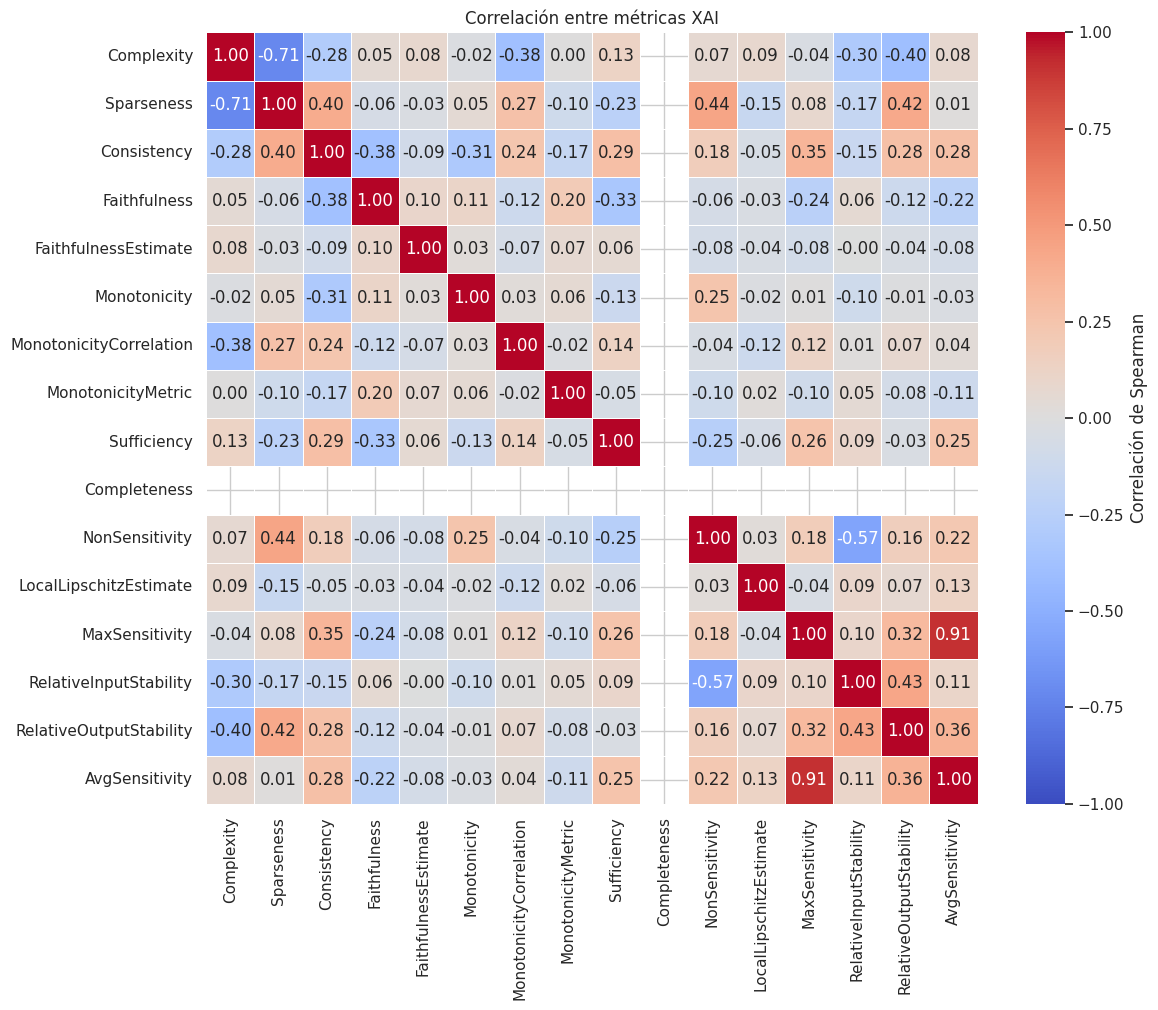

In [109]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 10))

metric_order = (
    pd.DataFrame({
        "metric": corr.columns,
        "category": [metric_categories.get(m) for m in corr.columns]
    })
    .sort_values(["category", "metric"])
    ["metric"]
    .tolist()
)

corr_ordered = corr.loc[metric_order, metric_order]

sns.heatmap(
    corr_ordered,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas XAI")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / "correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
corr_pairs = (
    corr.where(~pd.DataFrame(
        [[i >= j for j in range(len(corr.columns))] for i in range(len(corr.index))],
        index=corr.index,
        columns=corr.columns
    ))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

strong_corr = corr_pairs[
    corr_pairs["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

print(strong_corr)

          metric_1        metric_2  spearman_corr  abs_corr
5   AvgSensitivity  MaxSensitivity       0.909580  0.909580
25      Complexity      Sparseness      -0.712149  0.712149


In [21]:
mean_abs_corr = corr.abs().copy()

for col in mean_abs_corr.columns:
    mean_abs_corr.loc[col, col] = pd.NA

independence_summary = (
    mean_abs_corr.mean(axis=1)
    .sort_values()
    .reset_index()
)

independence_summary.columns = ["metric", "mean_abs_correlation"]

independence_summary

,metric,mean_abs_correlation
0,FaithfulnessEstimate,0.060859
1,LocalLipschitzEstimate,0.067622
2,MonotonicityMetric,0.080972
3,Monotonicity,0.082228
4,MonotonicityCorrelation,0.119603
5,Faithfulness,0.149591
6,RelativeInputStability,0.159221
7,Sufficiency,0.164960
8,Complexity,0.187283
9,NonSensitivity,0.188274


## Clustering jerárquico de métricas

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [23]:
Path('results').mkdir(exist_ok=True)

corr_cluster = corr.copy()

corr_cluster = corr_cluster.dropna(axis=0, how='all').dropna(axis=1, how='all')

valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics]

corr_cluster = corr_cluster.fillna(0)

distance = 1 - corr_cluster.abs()
np.fill_diagonal(distance.values, 0)

linkage_matrix = linkage(
    squareform(distance),
    method='average'
)

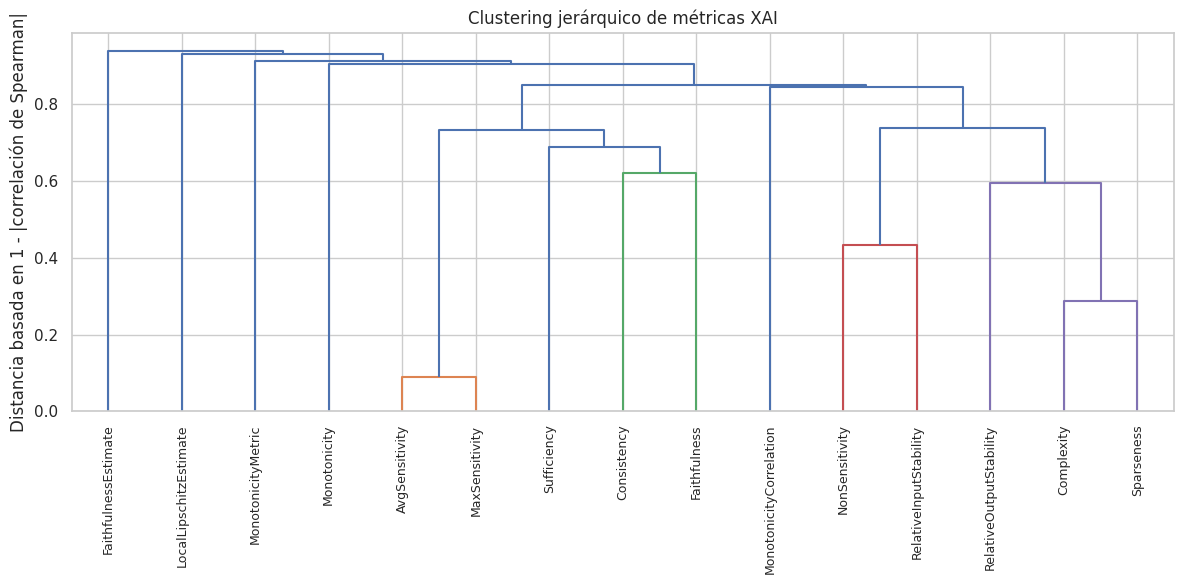

In [24]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=corr_cluster.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas XAI")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(output_dir / "dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

In [25]:
from scipy.stats import kruskal

In [26]:
sns.set_theme(style='whitegrid', context='notebook')

results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(exist_ok=True)

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

factors = ["dataset_name", "model_name", "xai_method"]

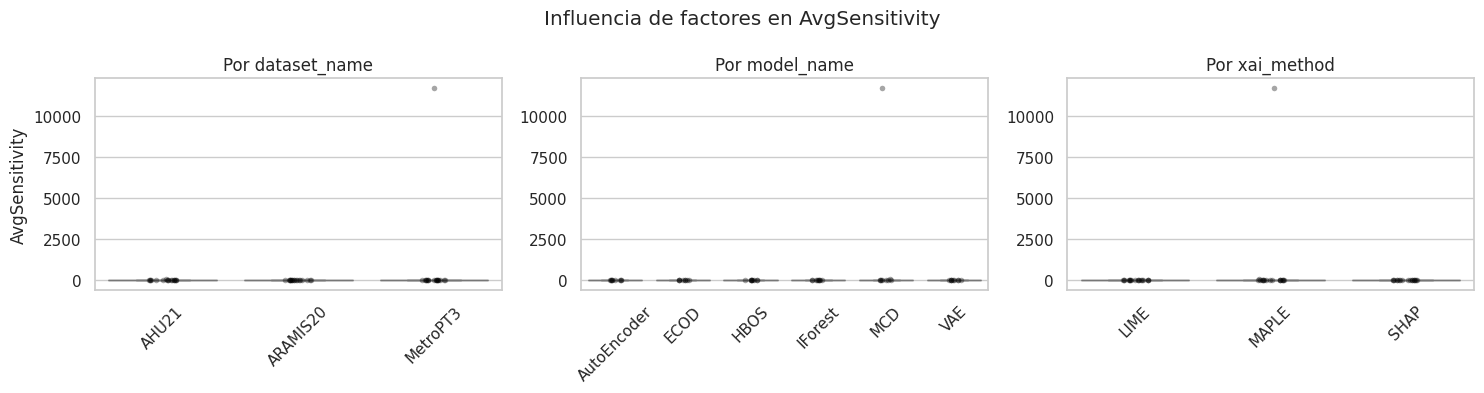

Saltando Completeness: no tiene variabilidad suficiente.


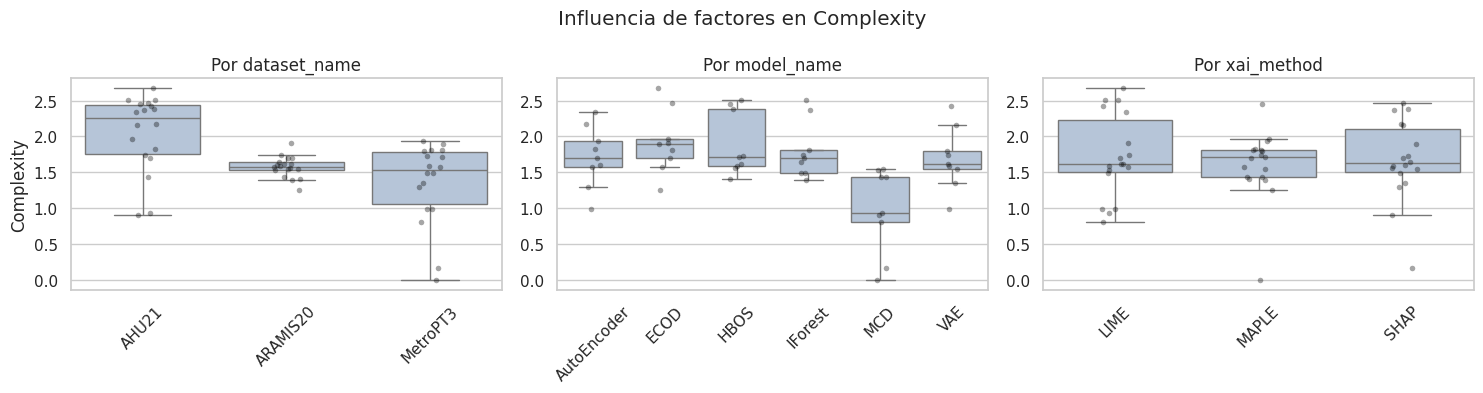

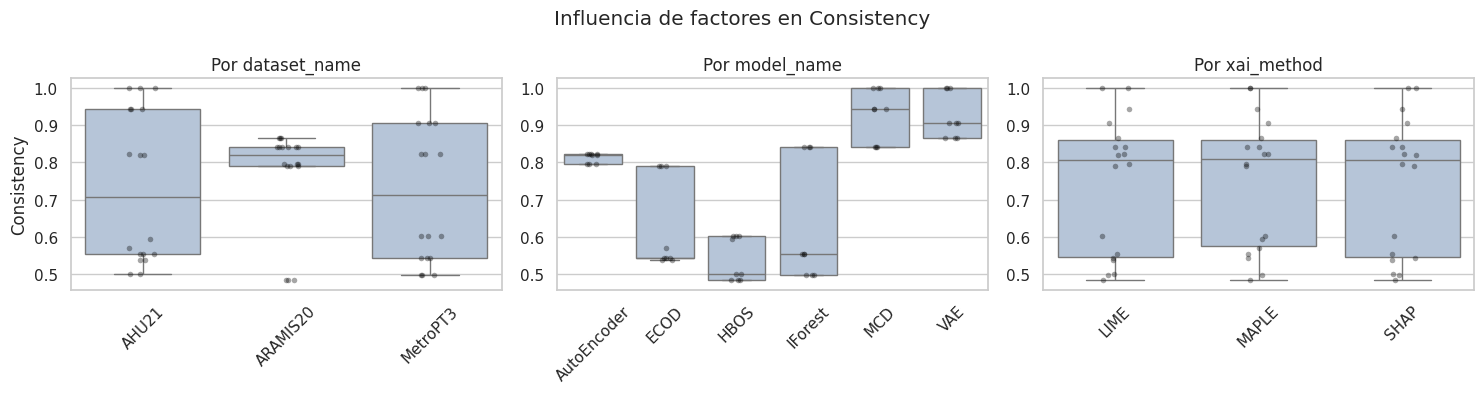

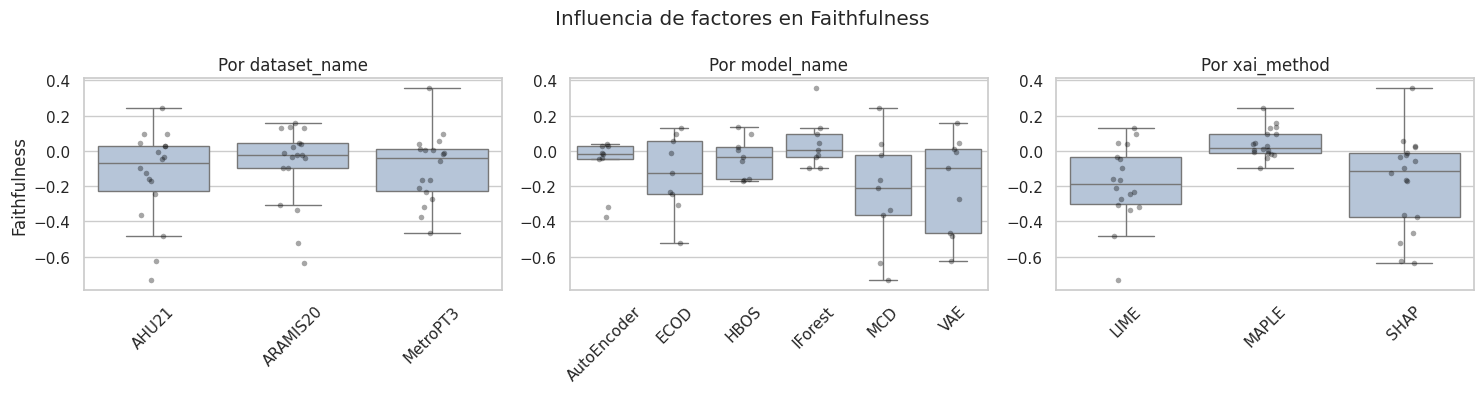

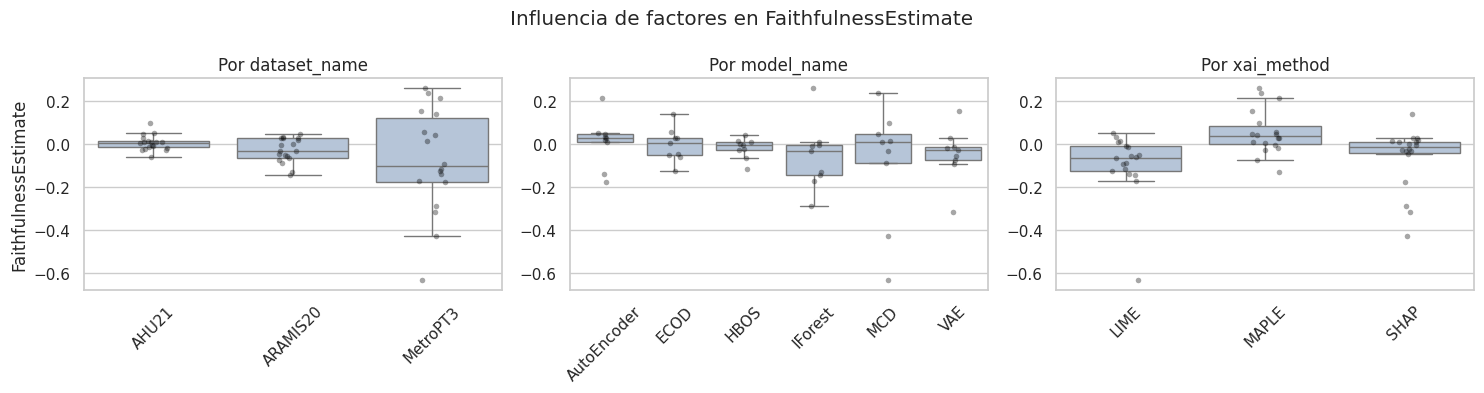

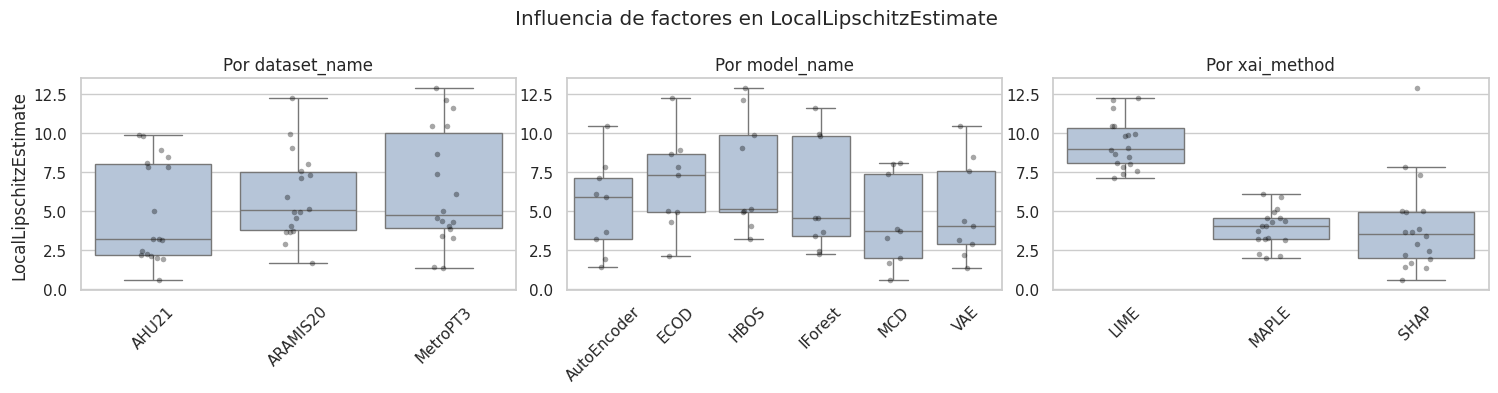

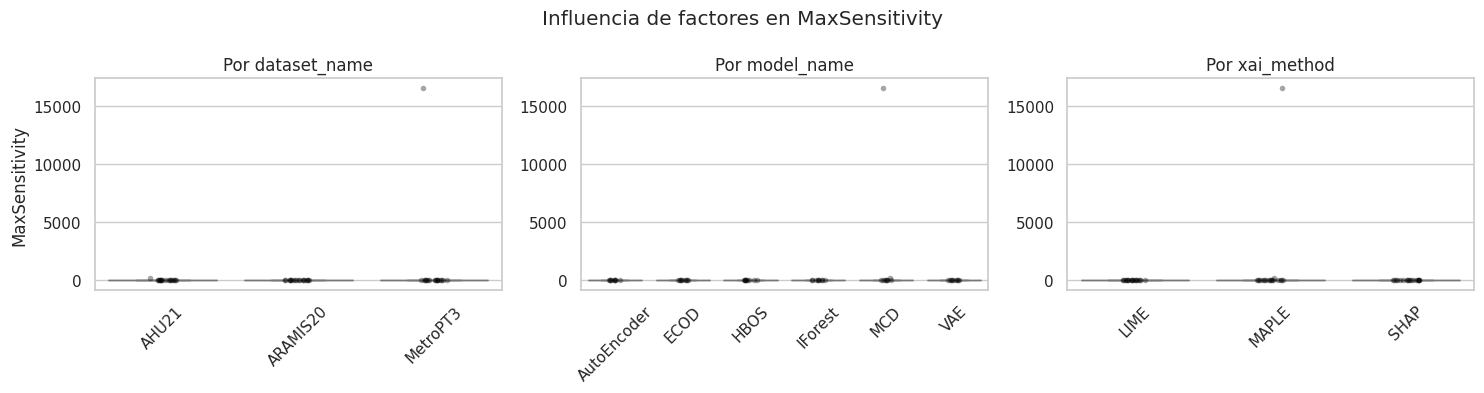

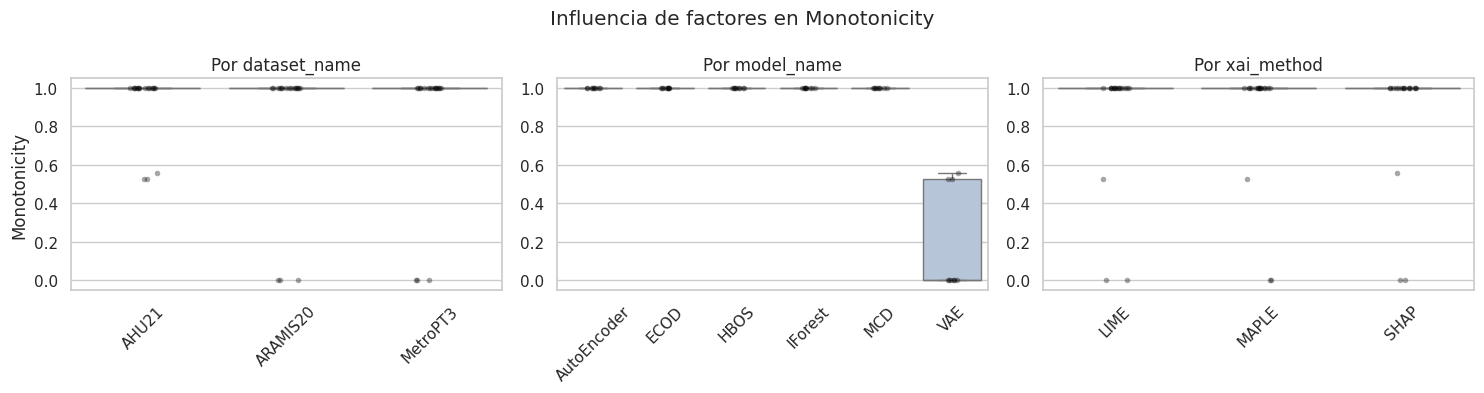

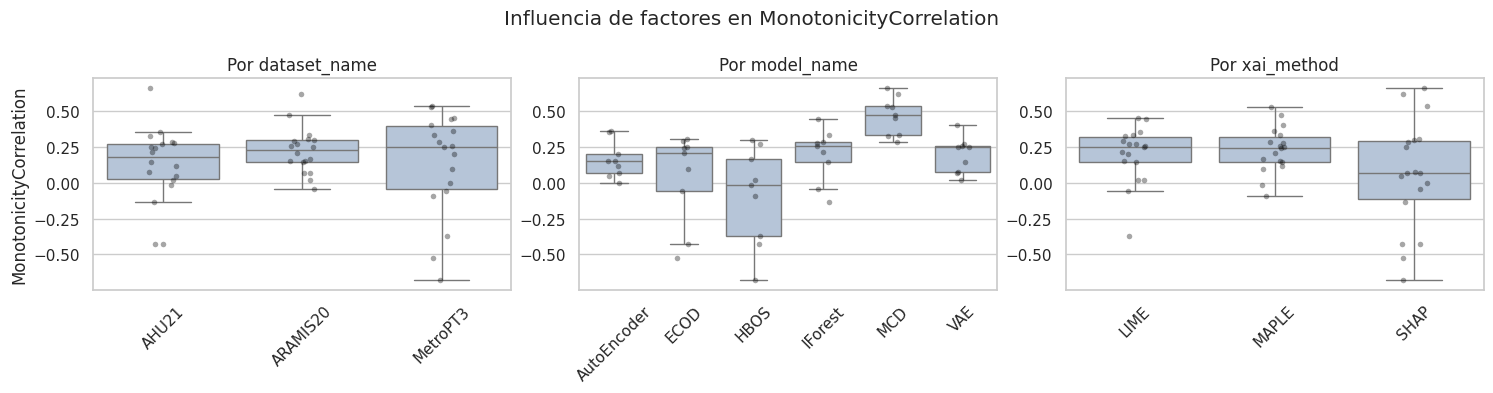

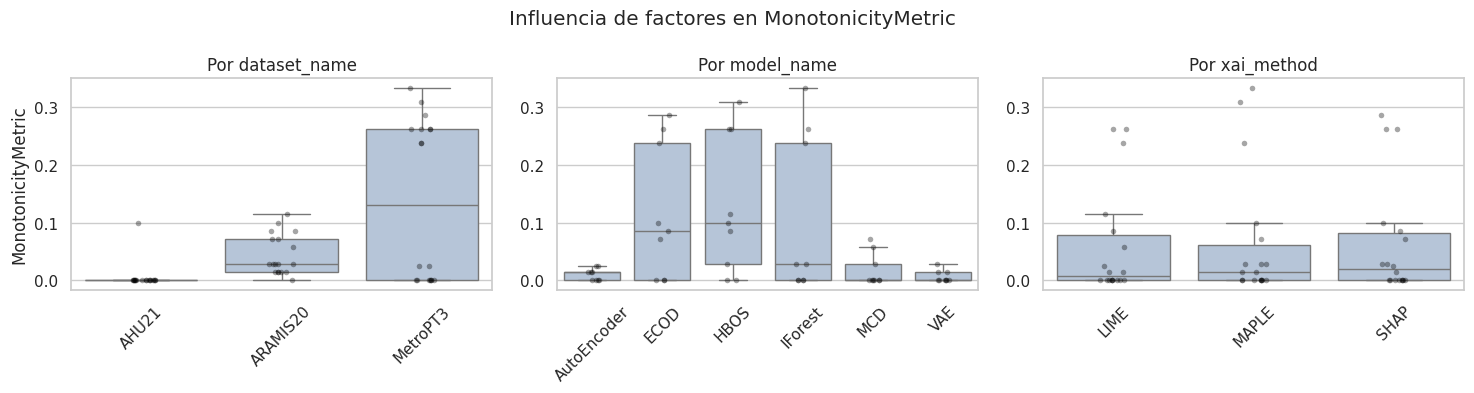

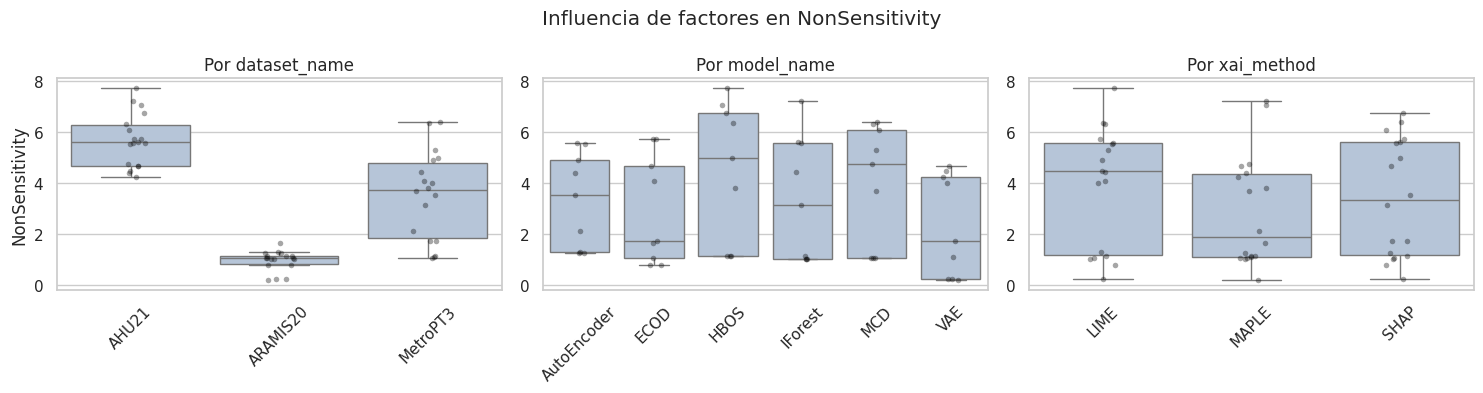

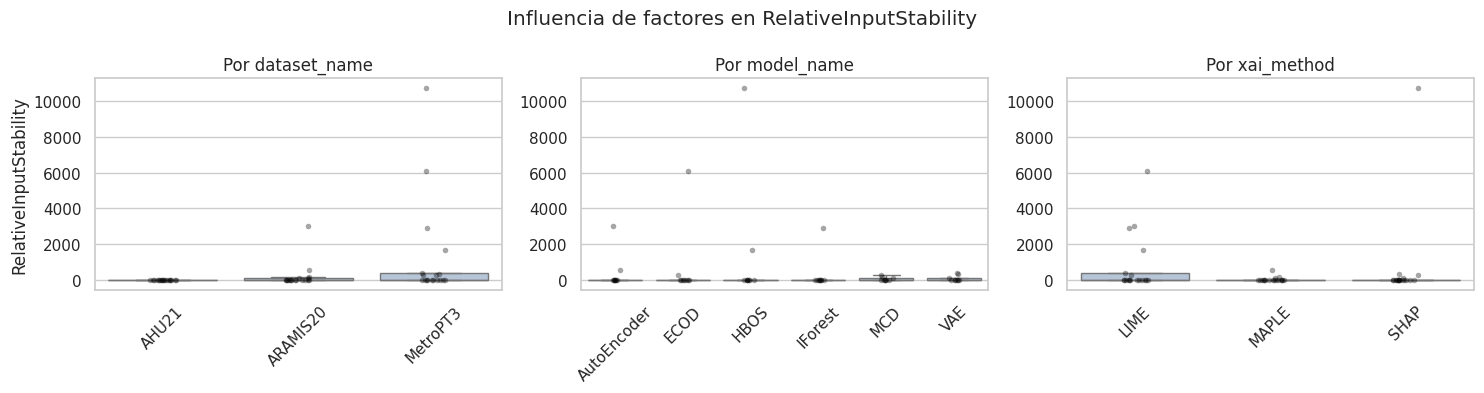

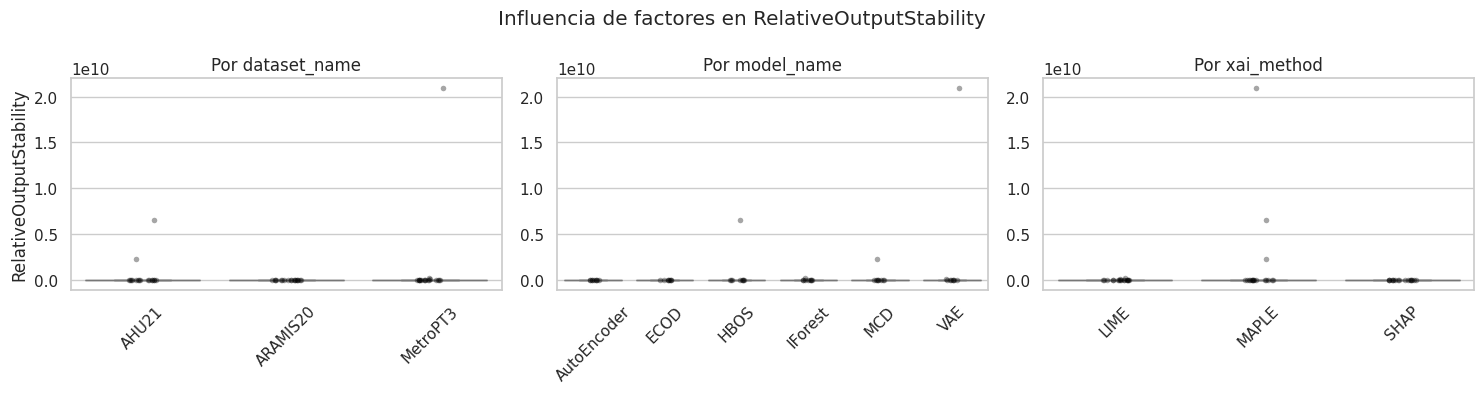

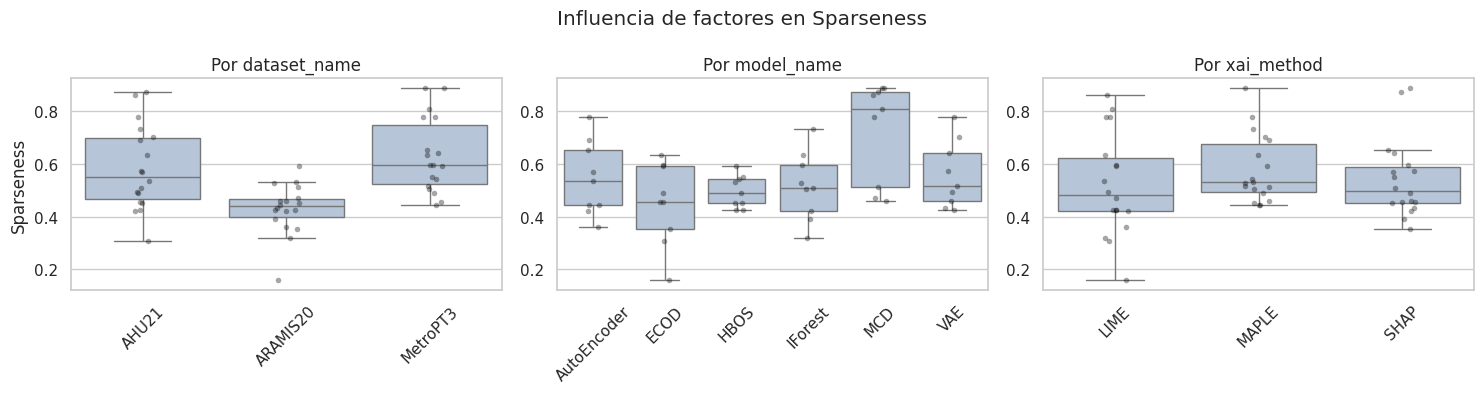

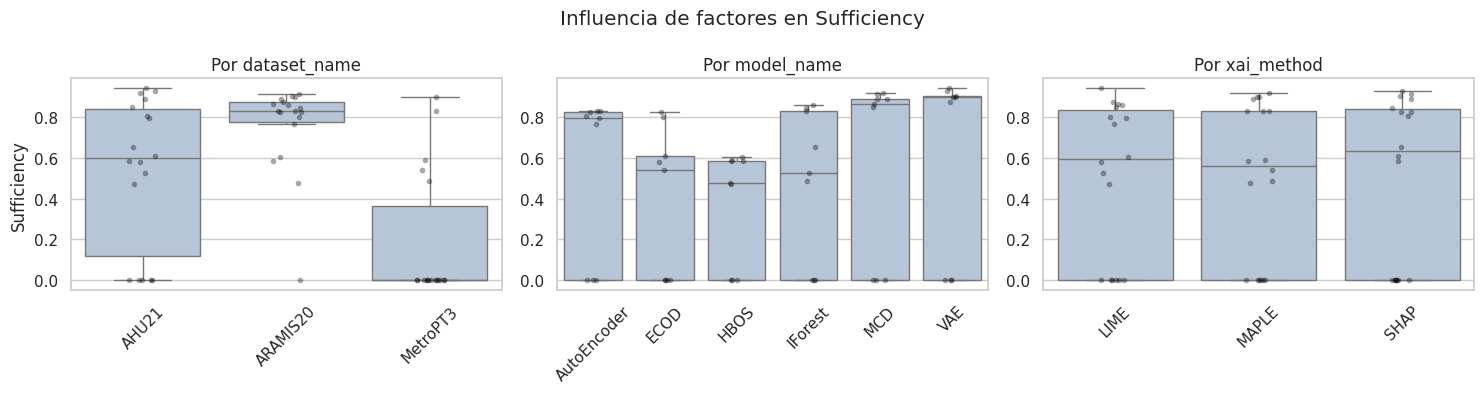

In [27]:
for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        print(f"Saltando {metric}: no tiene variabilidad suficiente.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric}")
    plt.tight_layout()
    plt.savefig(results_dir / f"{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [28]:
kruskal_results = []

for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        continue

    for factor in factors:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df = kruskal_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_df

,metric,factor,H,p_value,significant_0.05
7,Consistency,model_name,1763.831239,0.000000e+00,True
22,Monotonicity,model_name,2493.976433,0.000000e+00,True
30,NonSensitivity,dataset_name,2119.364611,0.000000e+00,True
17,LocalLipschitzEstimate,xai_method,1425.674422,2.622605e-310,True
33,RelativeInputStability,dataset_name,882.509997,2.319472e-192,True
3,Complexity,dataset_name,800.402795,1.565819e-174,True
42,Sufficiency,dataset_name,767.275372,2.444950e-167,True
4,Complexity,model_name,753.319386,1.448070e-160,True
39,Sparseness,dataset_name,710.233408,5.953536e-155,True
40,Sparseness,model_name,536.209458,1.215749e-113,True


In [29]:
kruskal_summary = kruskal_df.copy()

kruskal_summary["p_value"] = kruskal_summary["p_value"].round(4)
kruskal_summary["H"] = kruskal_summary["H"].round(3)

kruskal_summary

,metric,factor,H,p_value,significant_0.05
7,Consistency,model_name,1763.831,0.0000,True
22,Monotonicity,model_name,2493.976,0.0000,True
30,NonSensitivity,dataset_name,2119.365,0.0000,True
17,LocalLipschitzEstimate,xai_method,1425.674,0.0000,True
33,RelativeInputStability,dataset_name,882.510,0.0000,True
3,Complexity,dataset_name,800.403,0.0000,True
42,Sufficiency,dataset_name,767.275,0.0000,True
4,Complexity,model_name,753.319,0.0000,True
39,Sparseness,dataset_name,710.233,0.0000,True
40,Sparseness,model_name,536.209,0.0000,True


In [30]:
kruskal_summary.to_csv(
    results_dir / "kruskal_metric_factors.csv",
    index=False
)

## PCA

In [31]:
from sklearn.decomposition import PCA

In [32]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

X = analysis_df[valid_metric_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.166645,0.166645
1,PC2,0.135255,0.301899
2,PC3,0.113432,0.415331
3,PC4,0.088437,0.503768
4,PC5,0.073387,0.577154
5,PC6,0.068138,0.645293
6,PC7,0.067492,0.712785
7,PC8,0.064831,0.777616
8,PC9,0.059281,0.836897
9,PC10,0.052616,0.889513


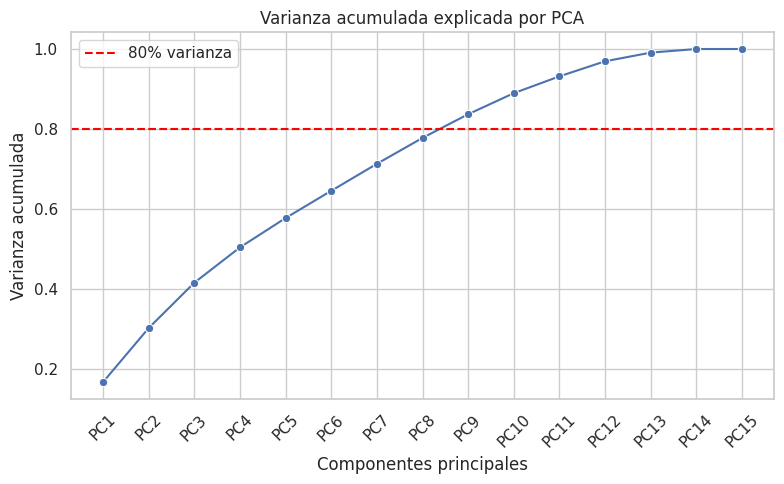

In [33]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_variance",
    marker="o"
)

plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=valid_metric_cols,
    columns=[f"PC{i+1}" for i in range(len(valid_metric_cols))]
)

loadings.iloc[:, :3].sort_values("PC1", key=abs, ascending=False)

,PC1,PC2,PC3
Complexity,0.481981,-0.009508,0.251108
Sparseness,-0.468726,-0.031351,-0.414035
Consistency,-0.374138,-0.392410,0.187864
MaxSensitivity,-0.341102,0.472239,0.360067
AvgSensitivity,-0.340256,0.472513,0.360920
MonotonicityCorrelation,-0.314143,-0.148600,-0.031320
Faithfulness,0.192862,0.379462,-0.193189
MonotonicityMetric,0.137924,0.191018,-0.058146
NonSensitivity,-0.087891,-0.023947,-0.375693
FaithfulnessEstimate,0.075356,0.113503,0.123815


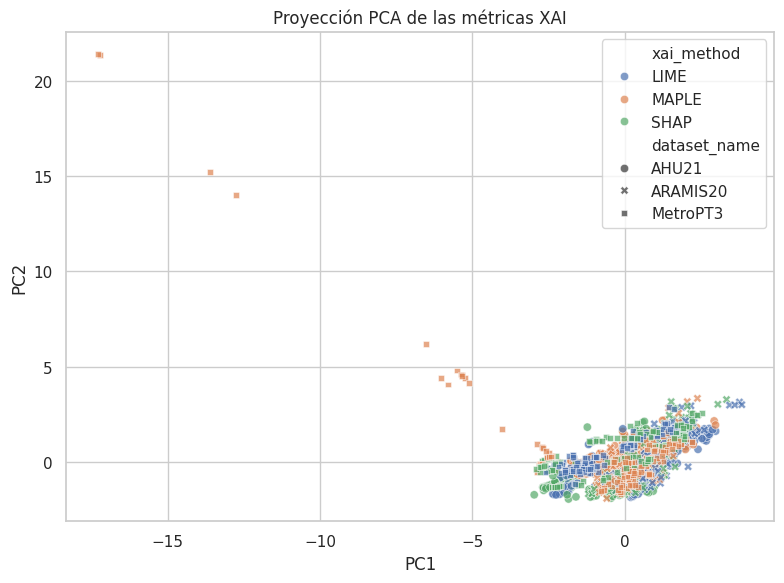

In [35]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df = pca_df.join(analysis_df.loc[X.index, ["dataset_name", "model_name", "xai_method"]])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="xai_method",
    style="dataset_name",
    alpha=0.7
)

plt.title("Proyección PCA de las métricas XAI")
plt.tight_layout()
plt.savefig(output_dir / "pca_metrics_projection.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis de métricas agregadas

In [36]:
matrix_path = Path("results/metric_analysis_agg_matrix.csv")
analysis_agg_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'xai_method']

results_dir = Path("results/conclusions_agg_results")
results_dir.mkdir(exist_ok=True)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


## Análisis descriptivo de las métricas

In [37]:
metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors='coerce')

summary_agg = analysis_agg_df[metric_cols_agg].describe().T

summary_agg['missing'] = analysis_agg_df[metric_cols_agg].isna().sum()
summary_agg['missing_pct'] = analysis_agg_df[metric_cols_agg].isna().mean() * 100
summary_agg['std'] = analysis_agg_df[metric_cols_agg].std()
summary_agg['range'] = summary_agg['max'] - summary_agg['min']
summary_agg['n_unique'] = analysis_agg_df[metric_cols_agg].nunique(dropna=True)

summary_agg = summary_agg[
    ['mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'n_unique']
].sort_values('std', ascending=False)

summary_agg

,mean,std,min,max,range,missing,missing_pct,n_unique
RelativeOutputStability,5.728378e+08,3.004384e+09,2.903308e+01,2.093812e+10,2.093812e+10,1,1.851852,53
MaxSensitivity,3.127231e+02,2.256974e+03,8.099279e-01,1.659008e+04,1.658927e+04,0,0.000000,54
RelativeInputStability,5.001405e+02,1.736796e+03,6.483567e-05,1.072343e+04,1.072343e+04,0,0.000000,54
AvgSensitivity,2.235261e+02,1.610481e+03,5.987122e-01,1.172666e+04,1.172606e+04,1,1.851852,53
LocalLipschitzEstimate,5.732717e+00,3.252305e+00,5.559809e-01,1.286683e+01,1.231085e+01,0,0.000000,54
NonSensitivity,3.369929e+00,2.267719e+00,1.714286e-01,7.714286e+00,7.542857e+00,0,0.000000,45
Complexity,1.663520e+00,5.349271e-01,-1.000089e-12,2.675365e+00,2.675365e+00,0,0.000000,54
Sufficiency,4.905452e-01,3.849659e-01,0.000000e+00,9.428571e-01,9.428571e-01,0,0.000000,36
Monotonicity,8.632275e-01,3.259370e-01,0.000000e+00,1.000000e+00,1.000000e+00,0,0.000000,4
SensitivityN,-1.192237e-01,2.767465e-01,-9.636733e-01,2.995004e-01,1.263174e+00,0,0.000000,54


In [38]:
sns.set_theme(style='whitegrid', context='notebook')

summary_agg_plot = summary_agg.copy()

summary_agg_plot = summary_agg_plot.drop(index=global_metrics, errors='ignore')

summary_agg_plot = summary_agg_plot.sort_values('std', ascending=False)

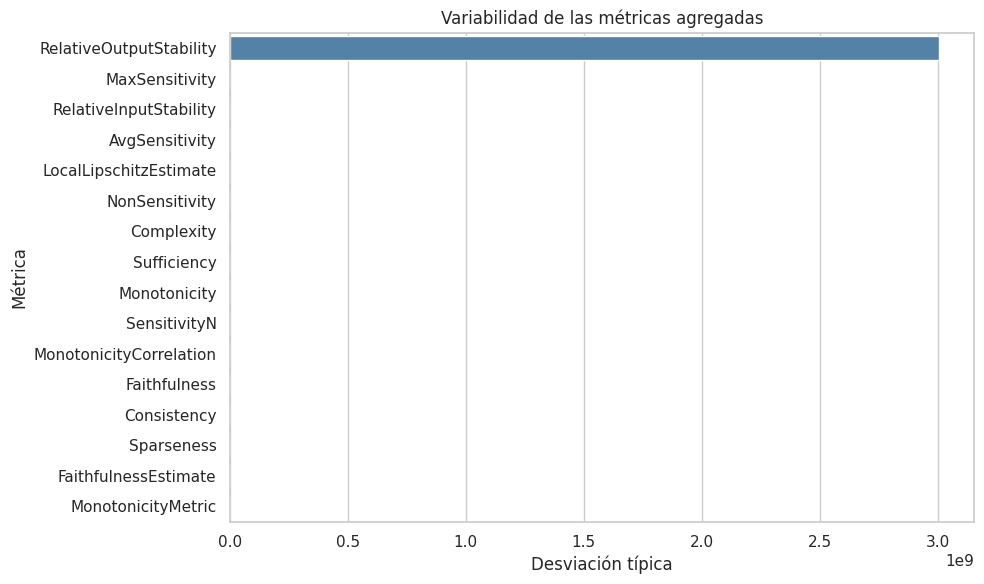

In [39]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

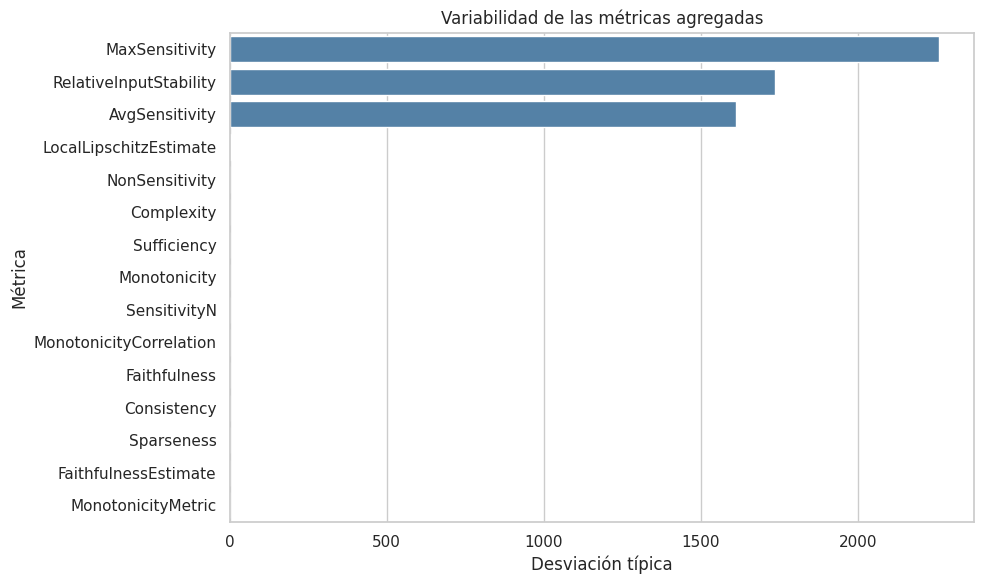

In [40]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

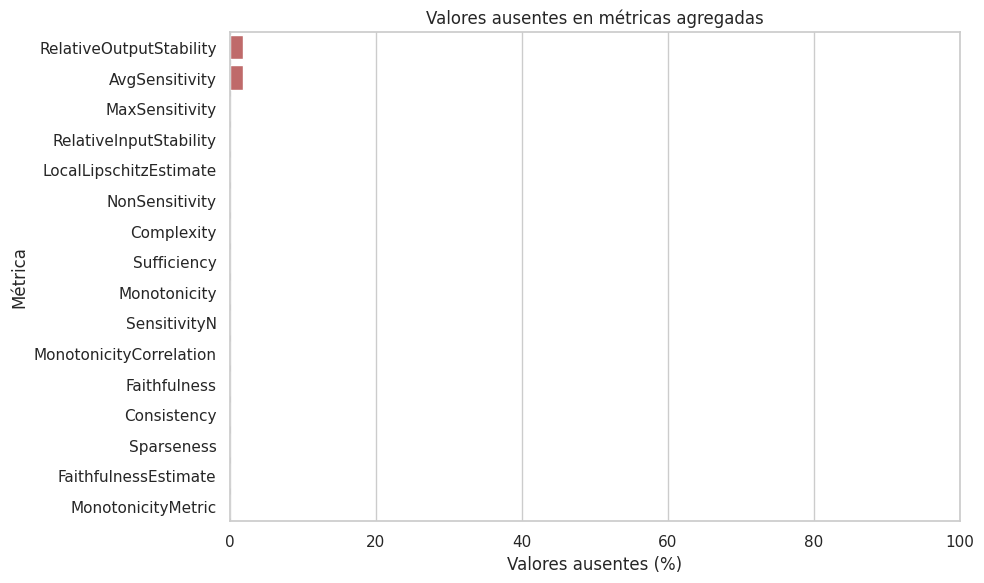

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.sort_values("missing_pct", ascending=False).reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)
plt.title("Valores ausentes en métricas agregadas")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_missing.png", dpi=300, bbox_inches="tight")
plt.show()

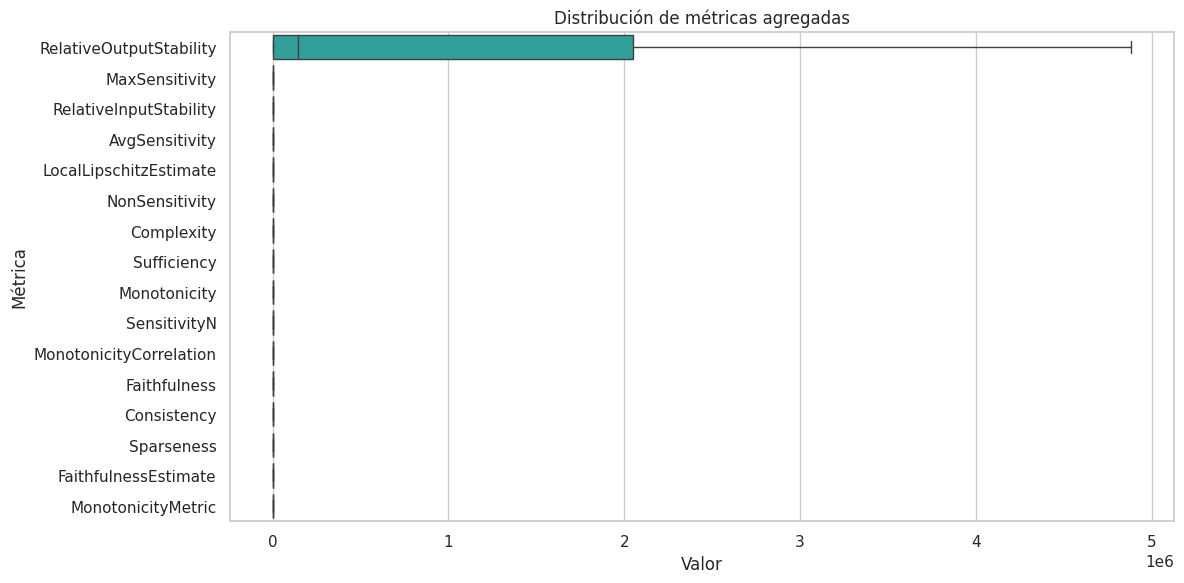

In [42]:
plot_long_agg = analysis_agg_df[summary_plot_agg.index].melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

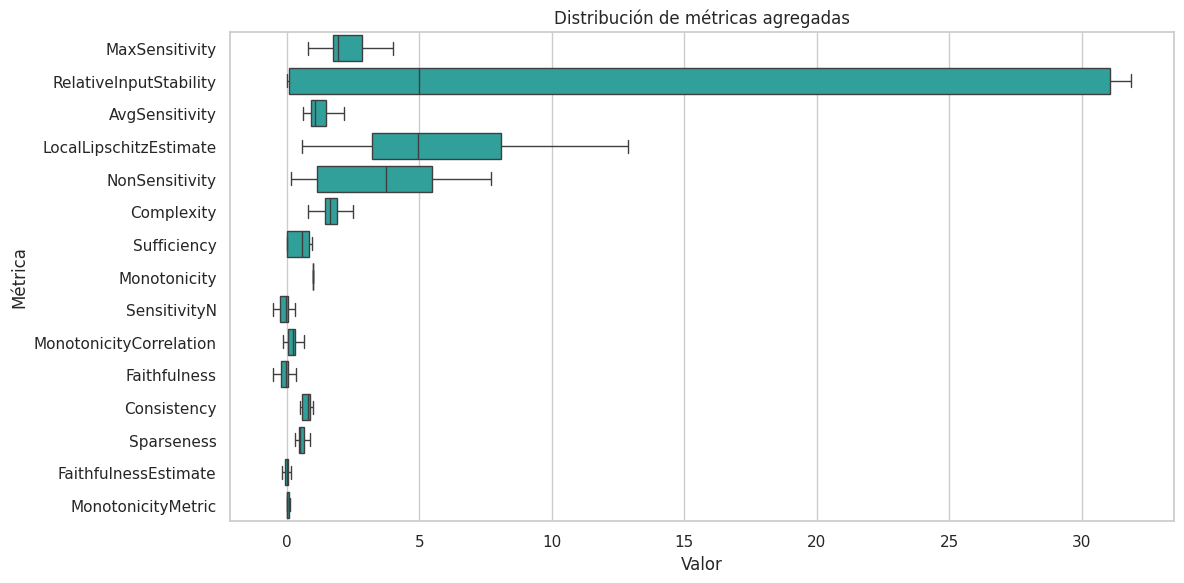

In [43]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

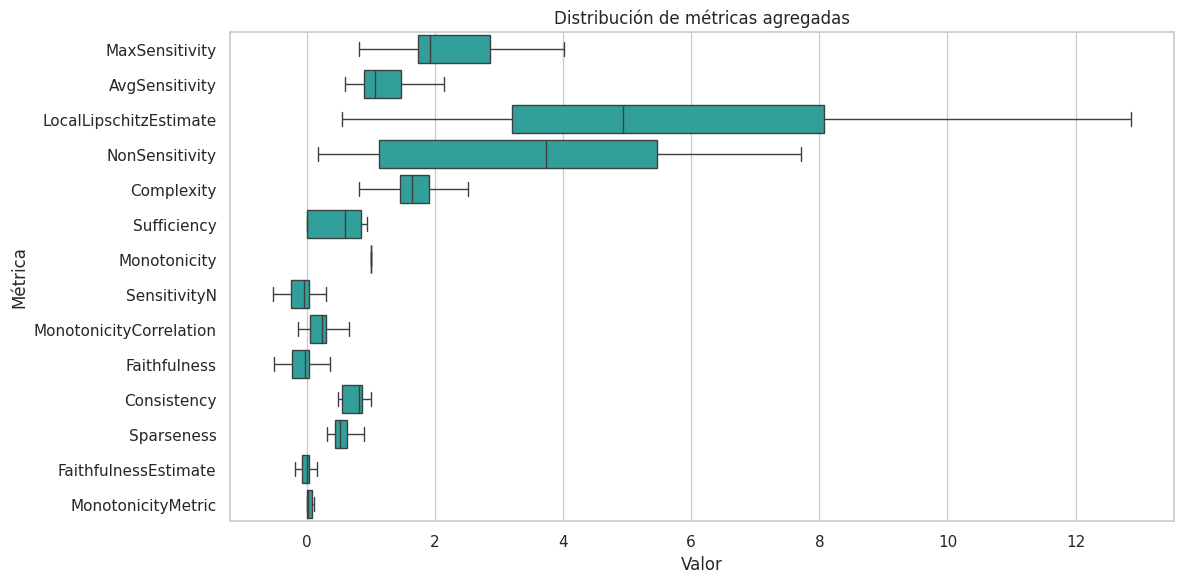

In [44]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability', 'RelativeInputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlación entre métricas

In [45]:
valid_metric_cols_agg = [
    c for c in metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

excluded_constant_agg = [
    c for c in metric_cols_agg
    if c not in valid_metric_cols_agg
]

print("Métricas excluidas por ser constantes o no tener variación:")
print(excluded_constant_agg)

X_agg = analysis_agg_df[valid_metric_cols_agg]

corr_agg = X_agg.corr(
    method="spearman",
    min_periods=5
)

corr_agg

Métricas excluidas por ser constantes o no tener variación:
['Completeness']


,AvgSensitivity,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
AvgSensitivity,1.000000,-0.126996,0.178779,-0.209079,0.042896,-0.123448,0.731737,0.045808,0.107321,-0.039242,0.205218,0.023141,0.221255,-0.039268,0.194404,0.158664
Complexity,-0.126996,1.000000,-0.408087,0.047456,0.304364,0.130017,-0.296360,0.022173,-0.433886,-0.139755,0.214461,-0.452563,-0.325996,0.149228,-0.553192,0.125533
Consistency,0.178779,-0.408087,1.000000,-0.275112,-0.080518,-0.277288,0.236476,-0.492983,0.332227,-0.479558,-0.097226,0.058184,0.253367,0.033559,0.368496,0.373377
Faithfulness,-0.209079,0.047456,-0.275112,1.000000,0.308024,-0.176215,-0.034420,0.085576,-0.100133,0.145906,-0.172599,0.051649,-0.090953,0.003087,-0.042958,-0.119920
FaithfulnessEstimate,0.042896,0.304364,-0.080518,0.308024,1.000000,-0.192682,0.103793,0.120277,-0.022222,-0.067304,-0.006443,-0.155937,0.080552,0.394321,-0.092281,0.218834
LocalLipschitzEstimate,-0.123448,0.130017,-0.277288,-0.176215,-0.192682,1.000000,-0.414828,0.122688,-0.058052,0.197370,0.022609,0.255117,-0.057813,-0.156470,-0.310921,-0.132782
MaxSensitivity,0.731737,-0.296360,0.236476,-0.034420,0.103793,-0.414828,1.000000,0.098162,0.103640,0.048810,0.104619,-0.013608,0.109015,0.094035,0.363141,0.082584
Monotonicity,0.045808,0.022173,-0.492983,0.085576,0.120277,0.122688,0.098162,1.000000,0.017880,0.253301,0.269440,-0.126041,-0.120817,0.038818,-0.037171,-0.258164
MonotonicityCorrelation,0.107321,-0.433886,0.332227,-0.100133,-0.022222,-0.058052,0.103640,0.017880,1.000000,-0.170834,-0.143317,-0.010787,0.176020,0.046846,0.255498,0.201219
MonotonicityMetric,-0.039242,-0.139755,-0.479558,0.145906,-0.067304,0.197370,0.048810,0.253301,-0.170834,1.000000,-0.428277,0.478649,-0.131075,-0.131714,-0.239304,-0.122997


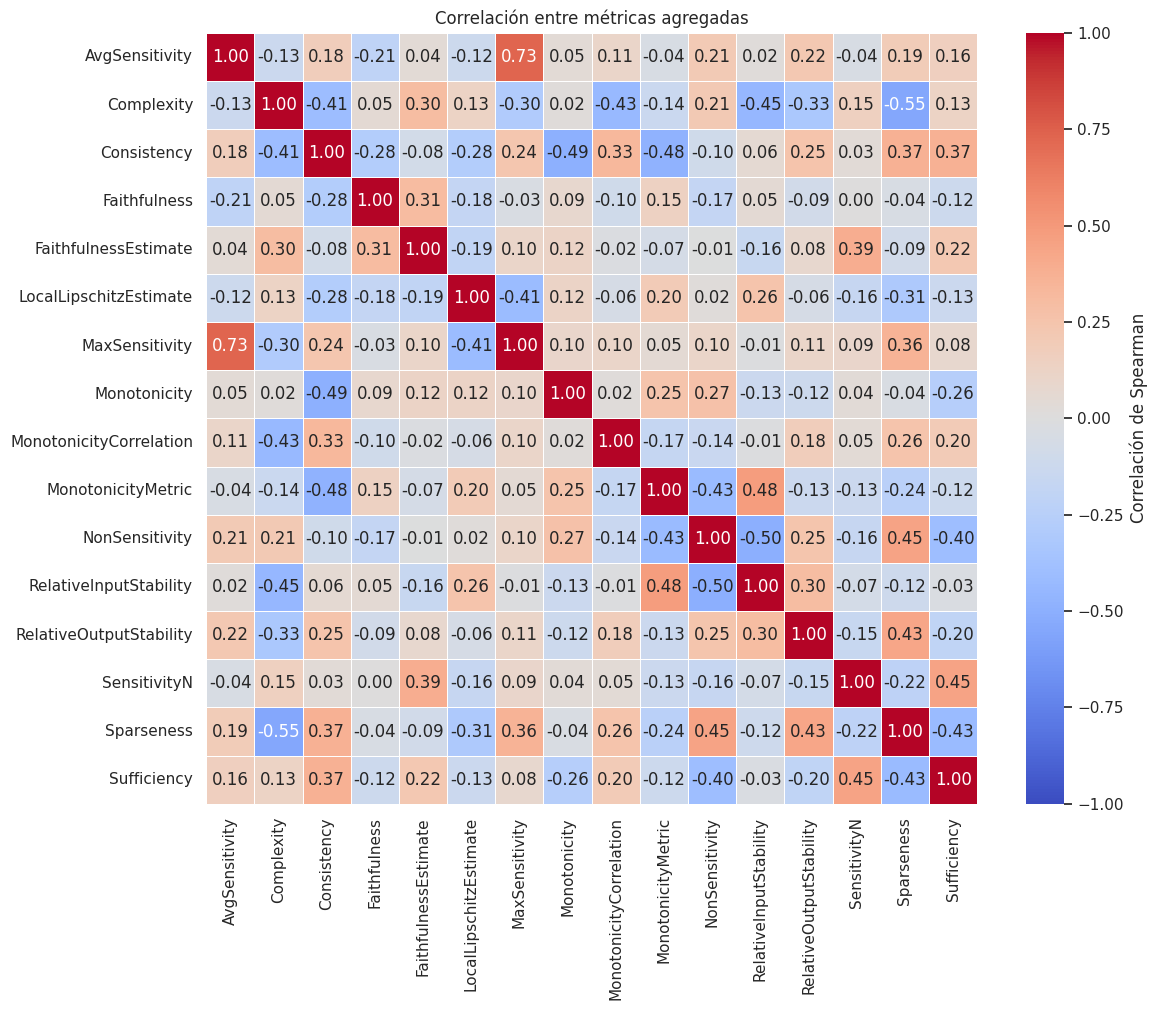

In [46]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_agg,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas agregadas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "agg_correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
corr_pairs_agg = (
    corr_agg.where(
        np.triu(np.ones(corr_agg.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs_agg.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs_agg["abs_corr"] = corr_pairs_agg["spearman_corr"].abs()

strong_corr_agg = corr_pairs_agg[
    corr_pairs_agg["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

strong_corr_agg

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.731737,0.731737


## Clustering jerárquico de métricas

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

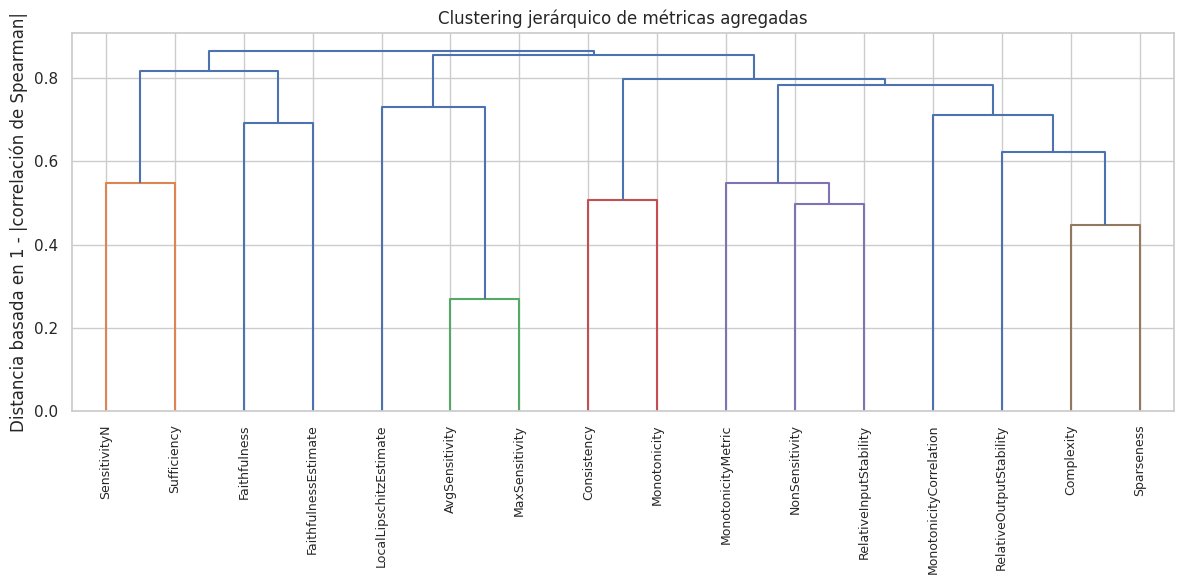

In [49]:
corr_cluster_agg = corr_agg.copy()

corr_cluster_agg = corr_cluster_agg.dropna(axis=0, how="all").dropna(axis=1, how="all")

valid_metrics_agg = corr_cluster_agg.index.intersection(corr_cluster_agg.columns)
corr_cluster_agg = corr_cluster_agg.loc[valid_metrics_agg, valid_metrics_agg]

corr_cluster_agg = corr_cluster_agg.fillna(0)

distance_agg = 1 - corr_cluster_agg.abs()
np.fill_diagonal(distance_agg.values, 0)

linkage_matrix_agg = linkage(
    squareform(distance_agg),
    method="average"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix_agg,
    labels=corr_cluster_agg.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas agregadas")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(results_dir / "agg_dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

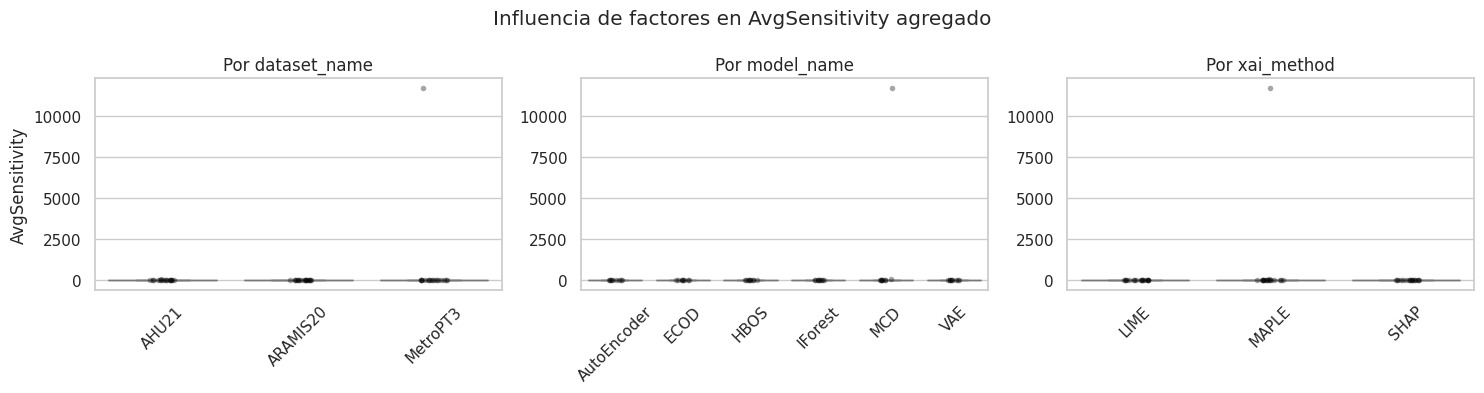

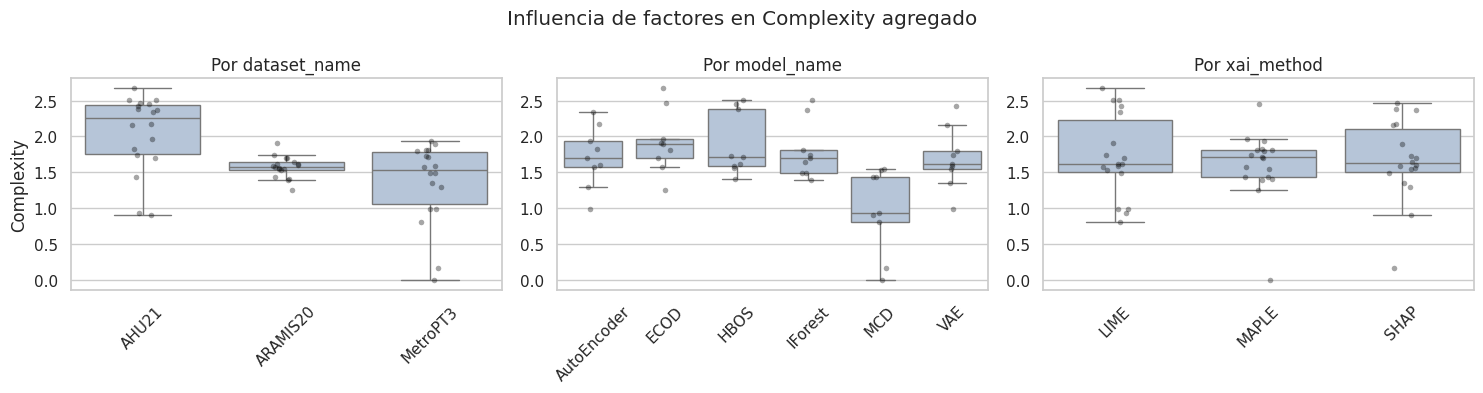

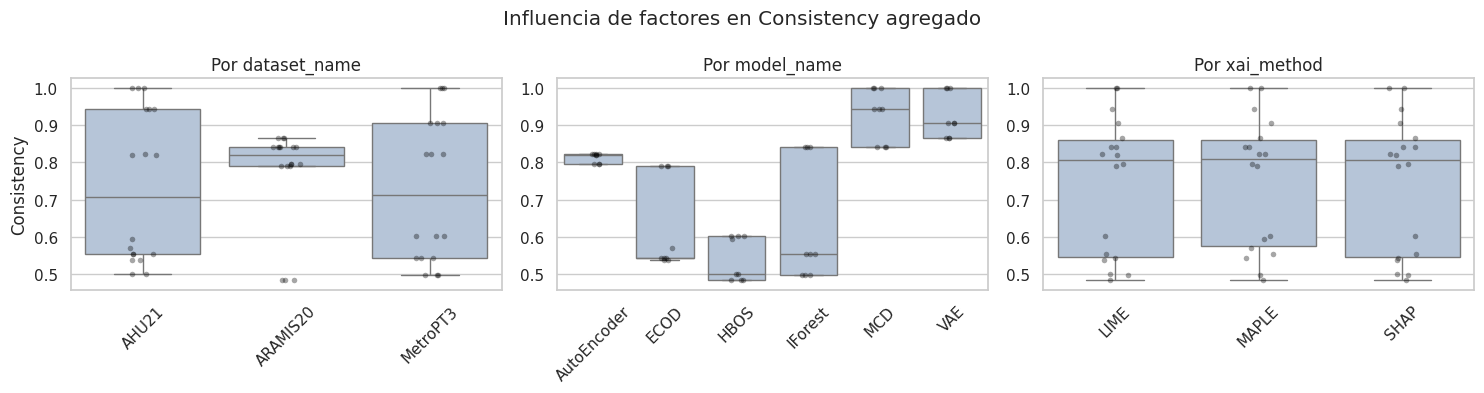

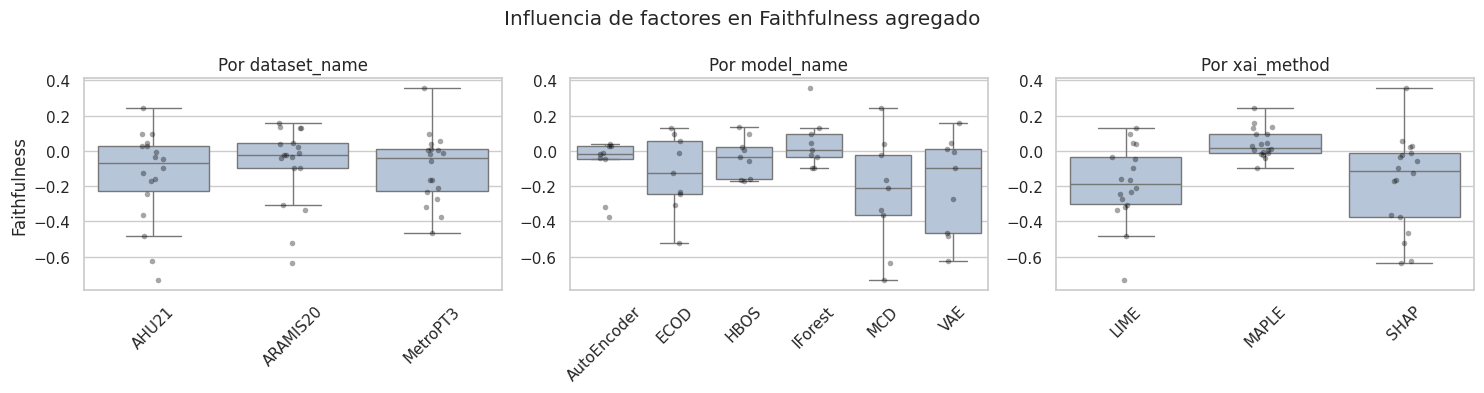

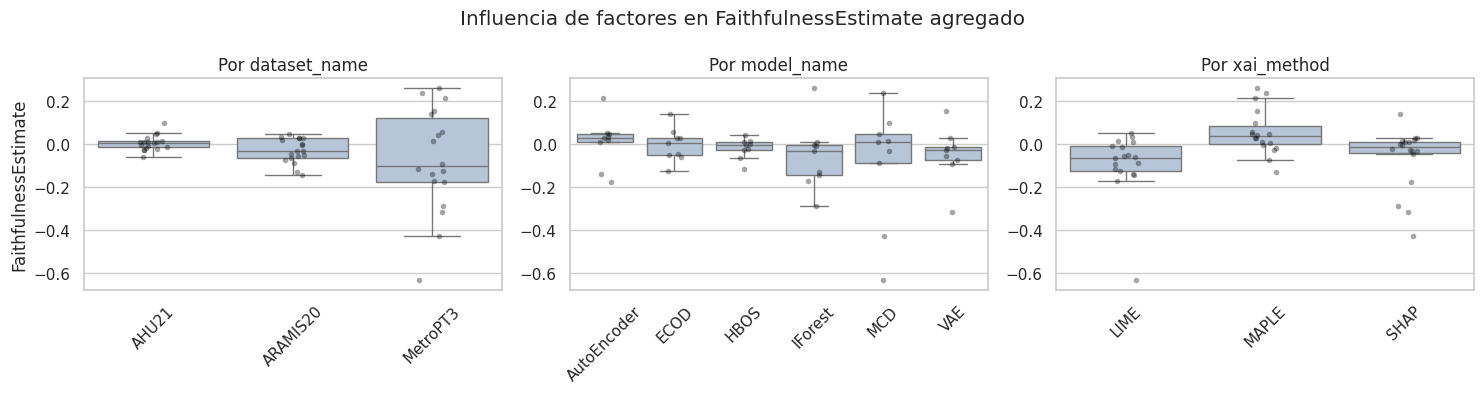

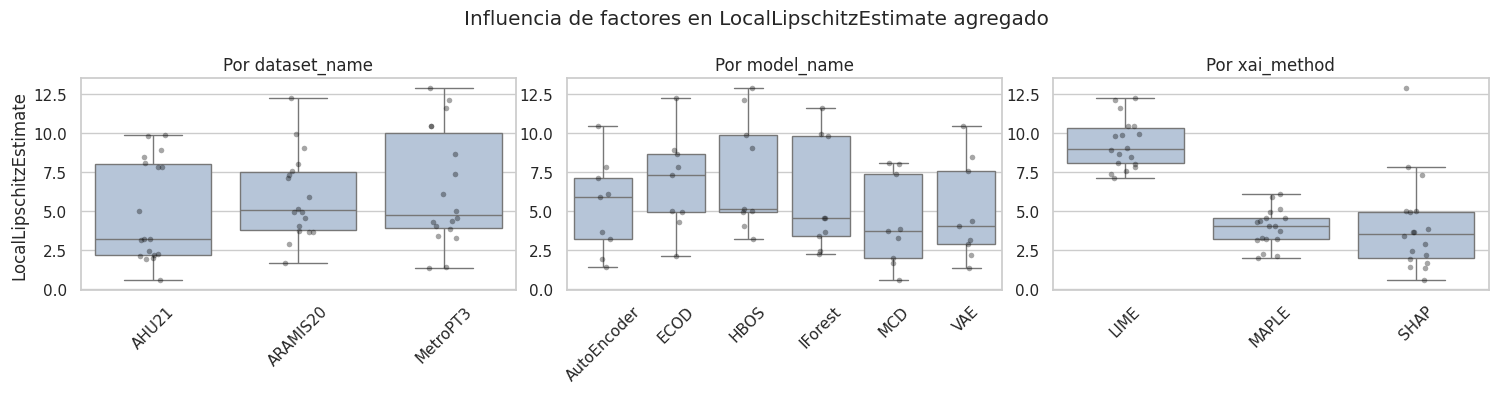

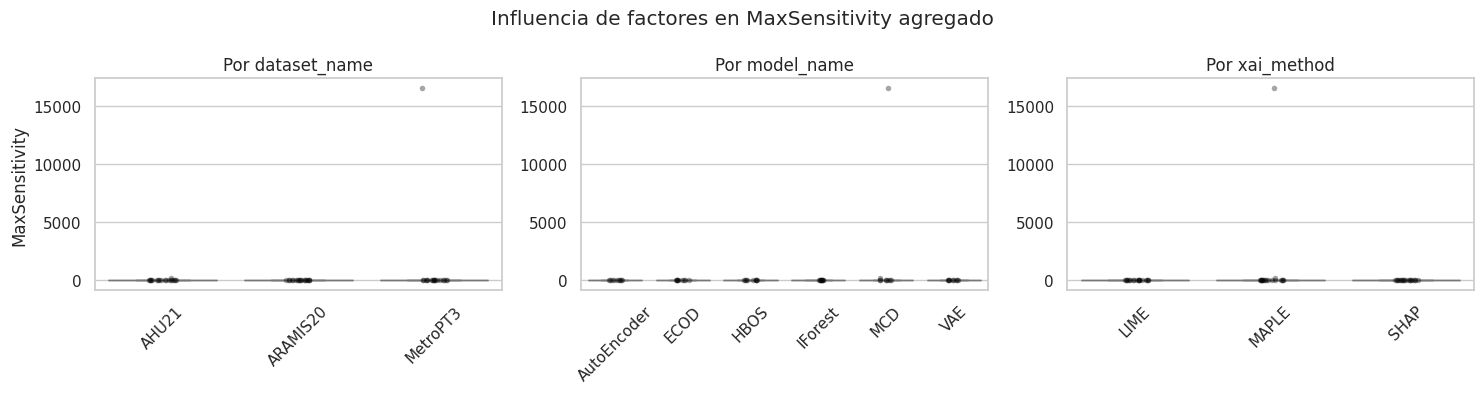

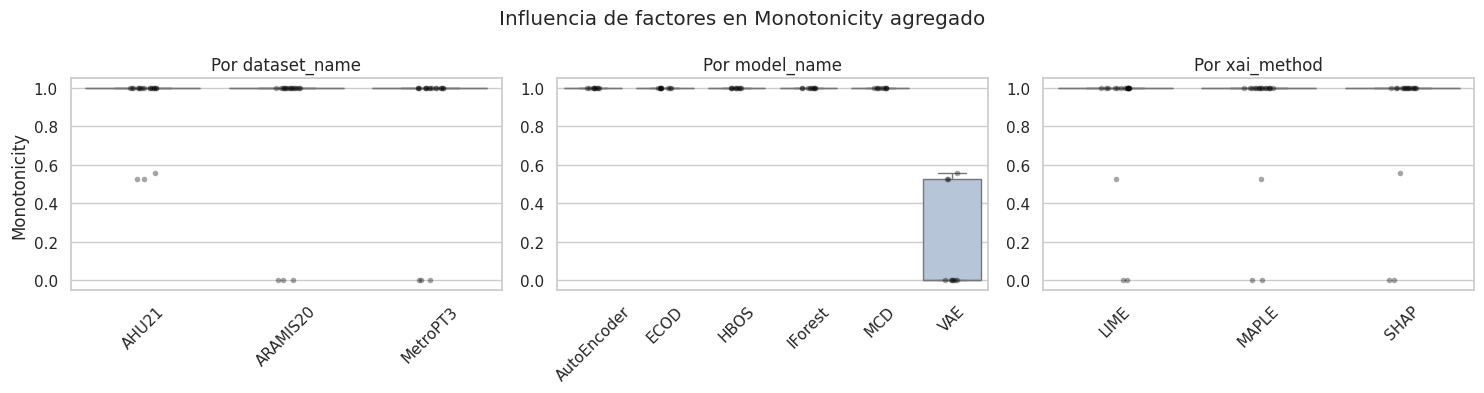

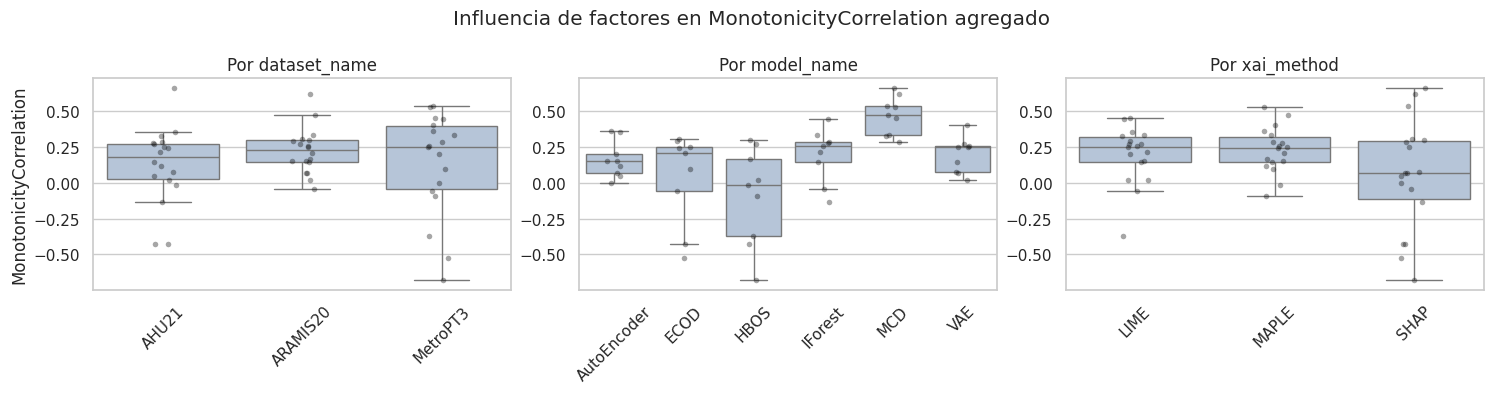

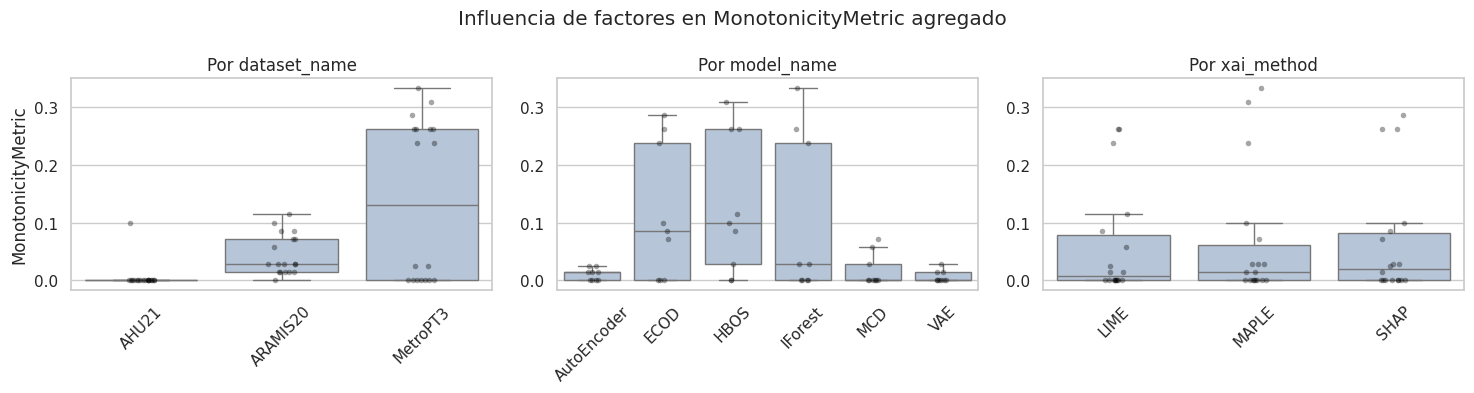

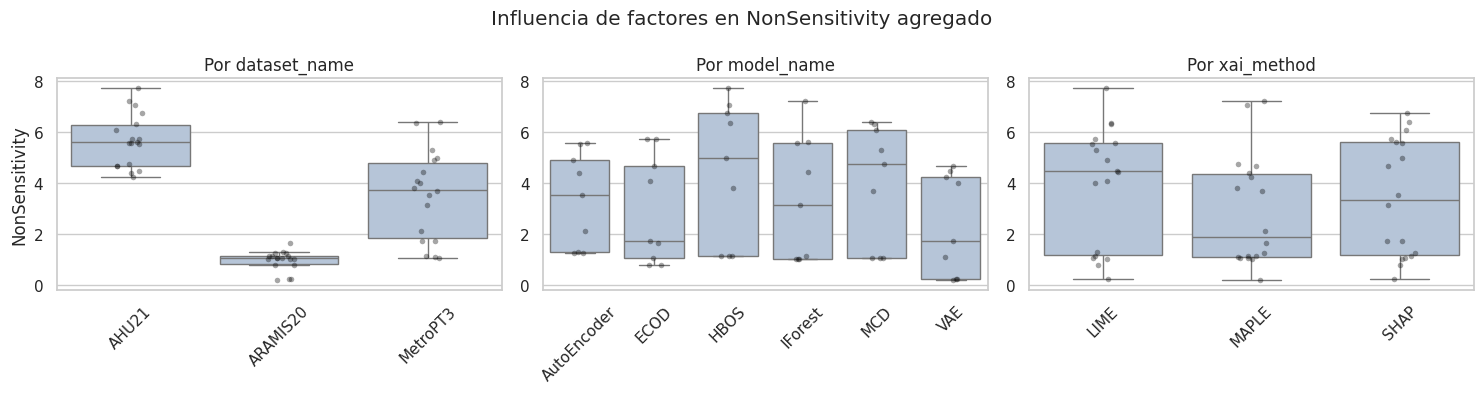

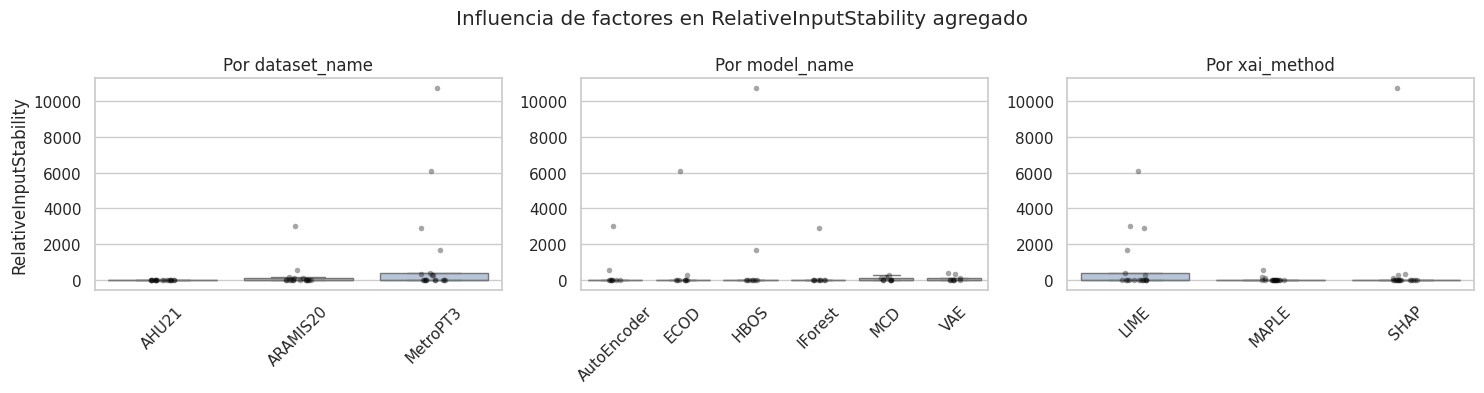

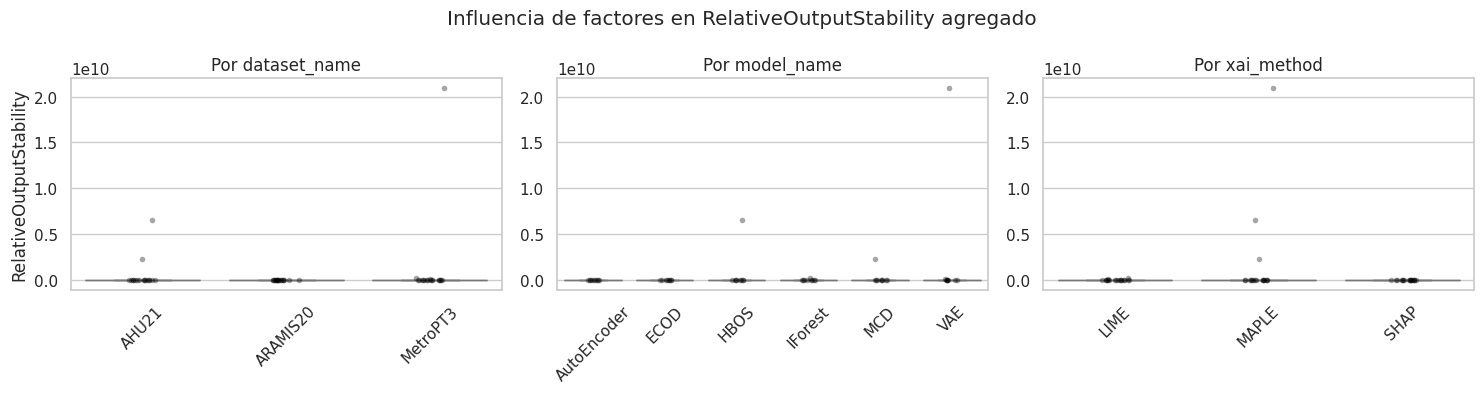

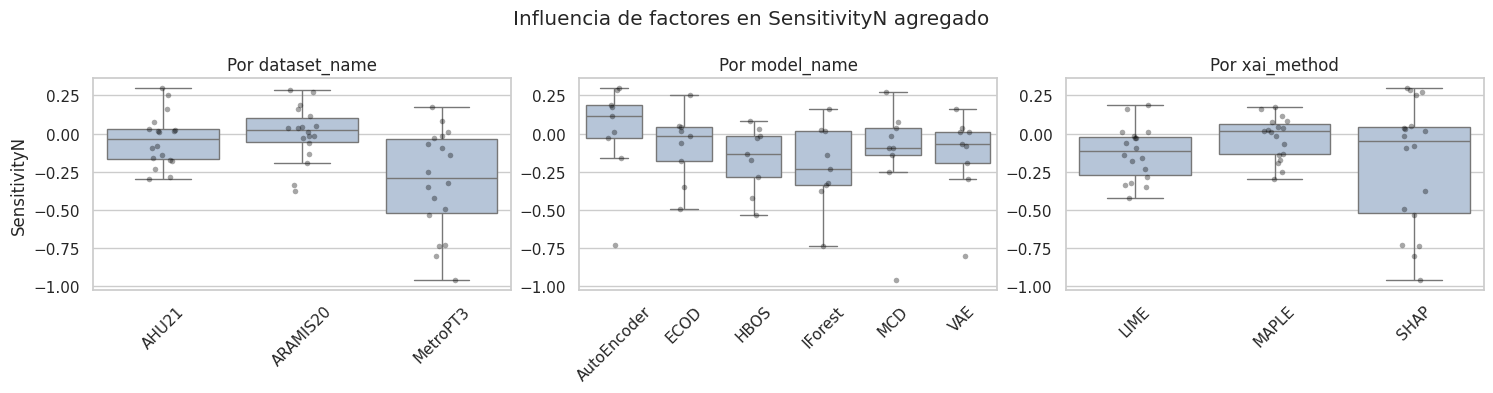

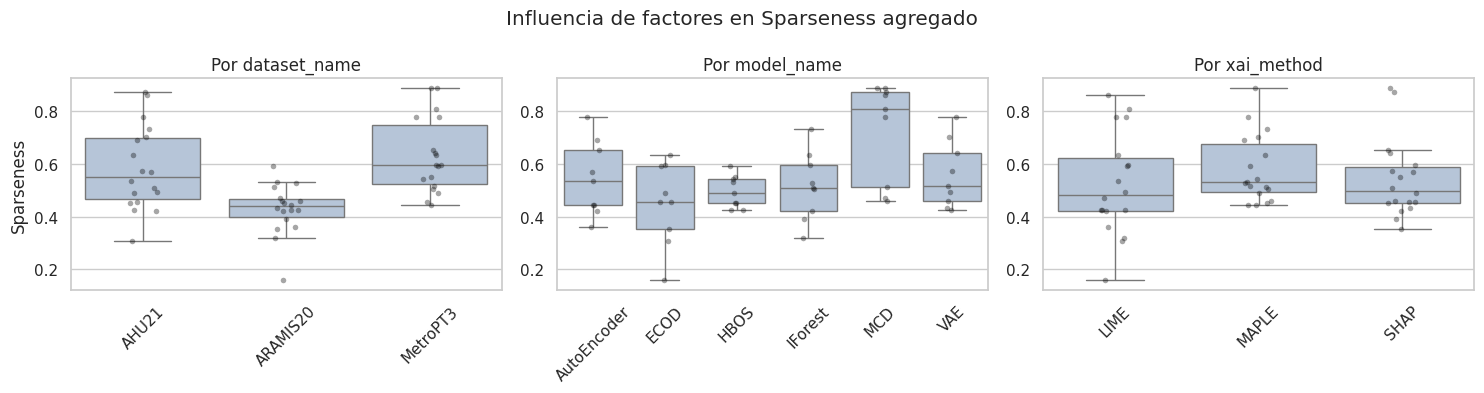

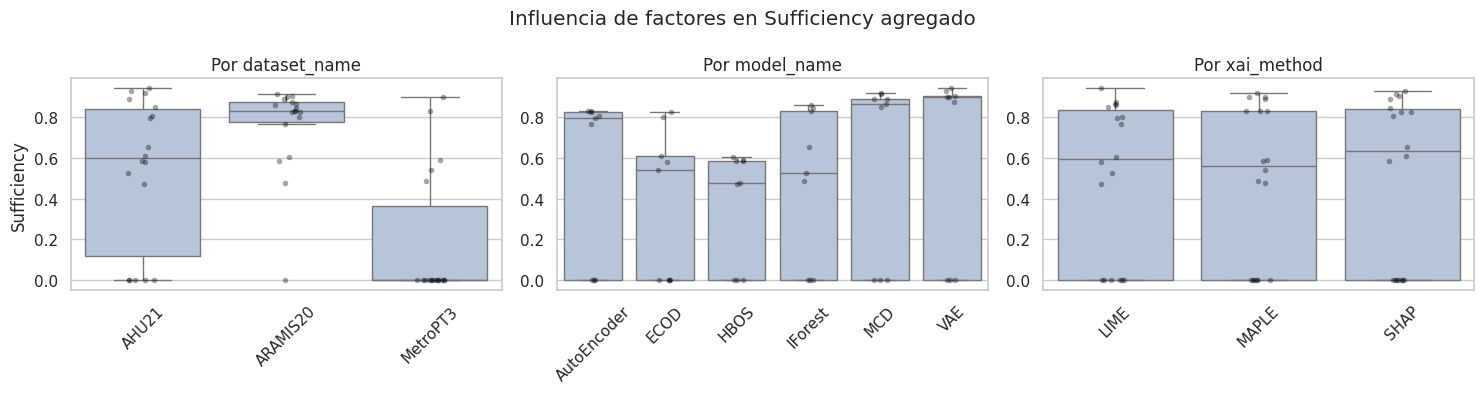

In [50]:
factors_agg = ["dataset_name", "model_name", "xai_method"]

selected_metrics_agg = [
    c for c in valid_metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

for metric in selected_metrics_agg:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors_agg):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors_agg[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric} agregado")
    plt.tight_layout()
    plt.savefig(results_dir / f"agg_{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [51]:
kruskal_results_agg = []

for metric in selected_metrics_agg:
    for factor in factors_agg:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_agg_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results_agg.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_agg_df = pd.DataFrame(kruskal_results_agg)

kruskal_agg_df = kruskal_agg_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_agg_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,52.595971,4.071044e-10,True
30,NonSensitivity,dataset_name,37.448860,7.380460e-09,True
33,RelativeInputStability,dataset_name,32.647811,8.139877e-08,True
7,Consistency,model_name,40.854040,1.004185e-07,True
17,LocalLipschitzEstimate,xai_method,30.823345,2.026729e-07,True
27,MonotonicityMetric,dataset_name,19.922700,4.718898e-05,True
42,Sparseness,dataset_name,18.330415,1.046167e-04,True
45,Sufficiency,dataset_name,17.180678,1.858931e-04,True
25,MonotonicityCorrelation,model_name,22.286644,4.618098e-04,True
3,Complexity,dataset_name,15.262402,4.850780e-04,True


# Analisis de métricas por modelo y método

In [52]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

matrix_path = Path("results/metric_analysis_matrix.csv")
results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(parents=True, exist_ok=True)

analysis_df = pd.read_csv(matrix_path)

id_cols = ["dataset_name", "model_name", "observation", "xai_method"]
excluded_metrics = ["SensitivityN", "Completeness"]

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in excluded_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


In [53]:
def safe_name(value):
    value = str(value)
    value = re.sub(r"[^a-zA-Z0-9_-]+", "_", value)
    return value.strip("_")


def run_metric_study_by_group(
    df,
    group_col,
    metric_cols,
    output_dir,
    remaining_factors=None,
    min_periods_corr=20,
    show_plots=False
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    for group_value, group_df in df.groupby(group_col):
        group_name = safe_name(group_value)
        group_dir = output_dir / f"{group_col}_{group_name}"
        group_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {group_col}: {group_value} =====")
        print(f"Filas: {len(group_df)}")

        valid_cols = [
            c for c in metric_cols
            if group_df[c].dropna().nunique() > 1
        ]

        excluded_cols = [
            c for c in metric_cols
            if c not in valid_cols
        ]

        print("Metricas validas:", valid_cols)
        print("Metricas excluidas:", excluded_cols)

        group_results = {}

        # A. Analisis descriptivo
        summary = group_df[metric_cols].describe().T
        summary["missing"] = group_df[metric_cols].isna().sum()
        summary["missing_pct"] = group_df[metric_cols].isna().mean() * 100
        summary["std"] = group_df[metric_cols].std()
        summary["range"] = summary["max"] - summary["min"]
        summary["n_unique"] = group_df[metric_cols].nunique(dropna=True)

        summary = summary[
            ["mean", "std", "min", "max", "range", "missing", "missing_pct", "n_unique"]
        ].sort_values("std", ascending=False)

        summary.to_csv(group_dir / "summary.csv")
        group_results["summary"] = summary

        # Grafica de variabilidad
        summary_plot = summary[summary["n_unique"] > 1].copy()

        if len(summary_plot) > 0:
            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=summary_plot.reset_index(),
                y="index",
                x="std",
                color="steelblue"
            )
            plt.title(f"Variabilidad de metricas - {group_col}: {group_value}")
            plt.xlabel("Desviacion tipica")
            plt.ylabel("Metrica")
            plt.tight_layout()
            plt.savefig(group_dir / "metric_std.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

        # B. Correlacion

        if len(valid_cols) >= 2:
            corr = group_df[valid_cols].corr(
                method="spearman",
                min_periods=min_periods_corr
            )

            p_values = pd.DataFrame(
                np.nan,
                index=valid_cols,
                columns=valid_cols
            )

            n_corr = pd.DataFrame(
                0,
                index=valid_cols,
                columns=valid_cols
            )

            for metric_1 in valid_cols:
                for metric_2 in valid_cols:
                    if metric_1 == metric_2:
                        pair_df = group_df[[metric_1]].dropna()
                        n_corr.loc[metric_1, metric_2] = len(pair_df)

                        if len(pair_df) >= min_periods_corr:
                            p_values.loc[metric_1, metric_2] = 0.0
                        continue

                    pair_df = group_df[[metric_1, metric_2]].dropna()
                    n_corr.loc[metric_1, metric_2] = len(pair_df)
                    
                    if len(pair_df) >= min_periods_corr:
                        stat, p_value = spearmanr(
                            pair_df[metric_1].to_numpy(),
                            pair_df[metric_2].to_numpy()
                        )
                        p_values.loc[metric_1, metric_2] = p_value

            corr.to_csv(group_dir / "correlation.csv")
            p_values.to_csv(group_dir / "correlation_p_values.csv")
            n_corr.to_csv(group_dir / "correlation_n.csv")

            group_results["corr"] = corr
            group_results["corr_p_values"] = p_values
            group_results["corr_n"] = n_corr

            plt.figure(figsize=(12, 10))
            sns.heatmap(
                corr,
                vmin=-1,
                vmax=1,
                center=0,
                cmap="coolwarm",
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                square=True,
                cbar_kws={"label": "Correlacion de Spearman"}
            )
            plt.title(f"Correlacion entre metricas - {group_col}: {group_value}")
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(group_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            corr_pairs = (
                corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                .stack()
                .reset_index()
            )

            corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]

            corr_pairs["p_value"] = corr_pairs.apply(
                lambda row: p_values.loc[row["metric_1"], row["metric_2"]],
                axis=1
            )

            corr_pairs["n"] = corr_pairs.apply(
                lambda row: n_corr.loc[row["metric_1"], row["metric_2"]],
                axis=1
            )

            corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()
            corr_pairs["significant_0.05"] = corr_pairs["p_value"] < 0.05
            corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

            strong_corr = corr_pairs[corr_pairs["abs_corr"] > 0.6]

            corr_pairs.to_csv(group_dir / "correlation_pairs.csv", index=False)
            strong_corr.to_csv(group_dir / "strong_correlations.csv", index=False)

            group_results["corr_pairs"] = corr_pairs
            group_results["strong_corr"] = strong_corr

            print("Correlaciones fuertes |rho| > 0.6:")
            print(strong_corr)

            # C. Clustering jerarquico
            corr_cluster = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")
            valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
            corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics].fillna(0)

            if len(corr_cluster) >= 3:
                distance = 1 - corr_cluster.abs()
                np.fill_diagonal(distance.values, 0)

                linkage_matrix = linkage(
                    squareform(distance),
                    method="average"
                )

                plt.figure(figsize=(12, 6))
                dendrogram(
                    linkage_matrix,
                    labels=corr_cluster.columns,
                    leaf_rotation=90,
                    leaf_font_size=9
                )
                plt.title(f"Clustering jerarquico - {group_col}: {group_value}")
                plt.ylabel("Distancia 1 - |rho|")
                plt.tight_layout()
                plt.savefig(group_dir / "dendrogram.png", dpi=300, bbox_inches="tight")
                if show_plots:
                    plt.show()
                plt.close()

        # D. PCA
        pca_df = group_df[valid_cols].dropna()

        if len(valid_cols) >= 2 and len(pca_df) >= 3:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(pca_df)

            pca = PCA()
            X_pca = pca.fit_transform(X_scaled)

            explained_variance = pd.DataFrame({
                "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                "explained_variance_ratio": pca.explained_variance_ratio_,
                "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
            })

            explained_variance.to_csv(group_dir / "pca_explained_variance.csv", index=False)
            group_results["pca_explained_variance"] = explained_variance

            plt.figure(figsize=(8, 5))
            sns.lineplot(
                data=explained_variance,
                x="component",
                y="cumulative_variance",
                marker="o"
            )
            plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
            plt.title(f"PCA - Varianza acumulada - {group_col}: {group_value}")
            plt.xlabel("Componentes principales")
            plt.ylabel("Varianza acumulada")
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.savefig(group_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            loadings = pd.DataFrame(
                pca.components_.T,
                index=valid_cols,
                columns=[f"PC{i+1}" for i in range(len(valid_cols))]
            )

            loadings.to_csv(group_dir / "pca_loadings.csv")
            group_results["pca_loadings"] = loadings

        # E. Kruskal-Wallis dentro del grupo
        if remaining_factors:
            kruskal_results = []

            for metric in valid_cols:
                for factor in remaining_factors:
                    if factor == group_col:
                        continue

                    groups = [
                        sub_group[metric].dropna().values
                        for _, sub_group in group_df.groupby(factor)
                    ]

                    groups = [g for g in groups if len(g) > 0]

                    if len(groups) > 1:
                        stat, p_value = kruskal(*groups)

                        kruskal_results.append({
                            "metric": metric,
                            "factor": factor,
                            "H": stat,
                            "p_value": p_value,
                            "significant_0.05": p_value < 0.05
                        })

            kruskal_df = pd.DataFrame(kruskal_results)

            if not kruskal_df.empty:
                kruskal_df = kruskal_df.sort_values(
                    ["p_value", "metric", "factor"],
                    ascending=[True, True, True]
                )

                kruskal_df.to_csv(group_dir / "kruskal_results.csv", index=False)
                group_results["kruskal"] = kruskal_df

                print("Kruskal-Wallis:")
                display(kruskal_df)

        results[group_value] = group_results

    return results

## Por modelo

In [54]:
model_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="model_name",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_model",
    remaining_factors=["dataset_name", "xai_method"],
    min_periods_corr=20,
    show_plots=False
)


===== model_name: AutoEncoder =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:
                  metric_1                 metric_2  spearman_corr  \
5           AvgSensitivity           MaxSensitivity       0.918248   
85  RelativeInputStability  RelativeOutputStability       0.654674   

          p_value    n  abs_corr  significant_0.05  
5   5.258456e-221  546  0.918248              True  
85   2.284001e-31  245  0.654674              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
18,NonSensitivity,dataset_name,329.987215,2.208955e-72,True
11,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True
24,Sparseness,dataset_name,230.190432,1.034625e-50,True
2,Complexity,dataset_name,220.924841,1.063605e-48,True
20,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True
4,Consistency,dataset_name,139.763626,4.474188e-31,True
22,RelativeOutputStability,dataset_name,112.589656,3.560138e-25,True
26,Sufficiency,dataset_name,90.164923,2.635941e-20,True
15,MonotonicityCorrelation,xai_method,39.215810,3.050669e-09,True
27,Sufficiency,xai_method,29.400018,4.129212e-07,True



===== model_name: ECOD =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:
                  metric_1                 metric_2  spearman_corr  \
5           AvgSensitivity           MaxSensitivity       0.716669   
85  RelativeInputStability  RelativeOutputStability       0.690371   
90              Sparseness              Sufficiency      -0.658639   
21              Complexity   RelativeInputStability      -0.646627   

         p_value    n  abs_corr  significant_0.05  
5   3.326462e-76  476  0.716669              True  
85  2.731199e-19  127  0.690371              True  
90  3.318381e-69  546  0.658639              True  
21  3.018353e-19  151  0.6466

,metric,factor,H,p_value,significant_0.05
18,NonSensitivity,dataset_name,343.726552,2.294709e-75,True
11,LocalLipschitzEstimate,xai_method,292.201115,3.542697e-64,True
2,Complexity,dataset_name,266.213815,1.557416e-58,True
25,Sparseness,xai_method,223.423421,3.049443e-49,True
4,Consistency,dataset_name,190.864724,3.583042e-42,True
27,Sufficiency,xai_method,145.956516,2.022764e-32,True
3,Complexity,xai_method,94.535165,2.964489e-21,True
20,RelativeInputStability,dataset_name,91.026712,1.713170e-20,True
14,MonotonicityCorrelation,dataset_name,86.033284,2.080223e-19,True
15,MonotonicityCorrelation,xai_method,84.516353,4.441269e-19,True



===== model_name: HBOS =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:
          metric_1                metric_2  spearman_corr        p_value    n  \
5   AvgSensitivity          MaxSensitivity       0.864966  5.009359e-165  546   
21      Complexity  RelativeInputStability      -0.684189   6.829593e-35  243   
20      Complexity          NonSensitivity       0.656795   1.064227e-68  546   

    abs_corr  significant_0.05  
5   0.864966              True  
21  0.684189              True  
20  0.656795              True  
Kruskal-Wallis:


...

,metric,factor,H,p_value,significant_0.05
18,NonSensitivity,dataset_name,401.947592,5.226240e-88,True
11,LocalLipschitzEstimate,xai_method,324.680414,3.137212e-71,True
26,Sufficiency,dataset_name,299.785911,7.985767e-66,True
4,Consistency,dataset_name,292.986263,2.392441e-64,True
2,Complexity,dataset_name,213.565548,4.215319e-47,True
24,Sparseness,dataset_name,124.437256,9.523423e-28,True
25,Sparseness,xai_method,122.642826,2.335870e-27,True
16,MonotonicityMetric,dataset_name,105.536270,1.210849e-23,True
20,RelativeInputStability,dataset_name,81.945206,1.606292e-18,True
15,MonotonicityCorrelation,xai_method,80.811276,2.831746e-18,True



===== model_name: MCD =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:
                  metric_1                metric_2  spearman_corr  \
5           AvgSensitivity          MaxSensitivity       0.950463   
23              Complexity              Sparseness      -0.901977   
83          NonSensitivity              Sparseness       0.757178   
13              Complexity             Consistency      -0.679232   
34             Consistency              Sparseness       0.675787   
86  RelativeInputStability              Sparseness      -0.668700   
81          NonSensitivity  RelativeInputStability      -0.666106   
31             Consistency          N

,metric,factor,H,p_value,significant_0.05
4,Consistency,dataset_name,431.862793,1.667962e-94,True
24,Sparseness,dataset_name,389.050708,3.301507e-85,True
18,NonSensitivity,dataset_name,373.129340,9.462227e-82,True
2,Complexity,dataset_name,331.709154,9.338399e-73,True
11,LocalLipschitzEstimate,xai_method,328.205336,5.384147e-72,True
26,Sufficiency,dataset_name,276.170271,1.072476e-60,True
20,RelativeInputStability,dataset_name,221.440974,8.216813e-49,True
22,RelativeOutputStability,dataset_name,158.219016,4.397209e-35,True
7,Faithfulness,xai_method,144.823494,3.564329e-32,True
15,MonotonicityCorrelation,xai_method,84.267895,5.028739e-19,True



===== model_name: VAE =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
          metric_1                metric_2  spearman_corr        p_value    n  \
5   AvgSensitivity          MaxSensitivity       0.939088  1.682390e-254  546   
35     Consistency  RelativeInputStability      -0.771744   3.270664e-83  415   
34     Consistency          NonSensitivity       0.755551  5.282415e-102  546   
95  NonSensitivity  RelativeInputStability      -0.656426   1.668441e-52  415   

    abs_corr  significant_0.05  
5   0.939088              True  
35  0.771744              True  
34  0.755551              True  
95  0.656426              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
4,Consistency,dataset_name,458.992421,2.143198e-100,True
20,NonSensitivity,dataset_name,396.067321,9.887215e-87,True
11,LocalLipschitzEstimate,xai_method,356.314701,4.238828e-78,True
22,RelativeInputStability,dataset_name,301.159204,4.018924e-66,True
14,Monotonicity,dataset_name,227.565820,3.843351e-50,True
24,RelativeOutputStability,dataset_name,185.286991,5.826949e-41,True
2,Complexity,dataset_name,181.362497,4.146047e-40,True
26,Sparseness,dataset_name,158.226120,4.381619e-35,True
28,Sufficiency,dataset_name,92.695360,7.438036e-21,True
7,Faithfulness,xai_method,77.840580,1.250641e-17,True


## Por método

In [55]:
xai_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="xai_method",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_xai_method",
    remaining_factors=["dataset_name", "model_name"],
    min_periods_corr=20,
    show_plots=False
)


===== xai_method: LIME =====
Filas: 1092
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
                    metric_1                 metric_2  spearman_corr  \
5             AvgSensitivity           MaxSensitivity       0.913971   
24                Complexity  RelativeOutputStability      -0.748489   
102  RelativeOutputStability               Sparseness       0.717276   
25                Complexity               Sparseness      -0.693521   

           p_value     n  abs_corr  significant_0.05  
5     0.000000e+00  1092  0.913971              True  
24   1.183059e-104   577  0.748489              True  
102   2.811762e-92   577  0.717276              True  
25  

,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,835.242872,2.744174e-178,True
20,NonSensitivity,dataset_name,776.933765,1.954234e-169,True
5,Consistency,model_name,620.546870,7.345780e-132,True
28,Sufficiency,dataset_name,542.298355,1.743446e-118,True
26,Sparseness,dataset_name,520.417651,9.834290e-114,True
2,Complexity,dataset_name,499.469615,3.479774e-109,True
22,RelativeInputStability,dataset_name,422.036139,2.269953e-92,True
3,Complexity,model_name,349.952835,1.791671e-73,True
27,Sparseness,model_name,340.482939,1.958177e-71,True
24,RelativeOutputStability,dataset_name,263.687480,5.507966e-58,True



===== xai_method: MAPLE =====
Filas: 1092
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
                   metric_1        metric_2  spearman_corr       p_value  \
5            AvgSensitivity  MaxSensitivity       0.869200  0.000000e+00   
101  RelativeInputStability     Sufficiency       0.629015  5.380444e-65   

        n  abs_corr  significant_0.05  
5    1092  0.869200              True  
101   578  0.629015              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,835.242872,2.744174e-178,True
20,NonSensitivity,dataset_name,654.207916,8.720794e-143,True
5,Consistency,model_name,528.696390,5.094808e-112,True
2,Complexity,dataset_name,239.092769,1.206882e-52,True
26,Sparseness,dataset_name,215.185903,1.874886e-47,True
22,RelativeInputStability,dataset_name,209.965175,2.550596e-46,True
29,Sufficiency,model_name,216.462820,8.503438e-45,True
10,LocalLipschitzEstimate,dataset_name,198.569758,7.605448e-44,True
28,Sufficiency,dataset_name,185.218356,6.030385e-41,True
25,RelativeOutputStability,model_name,168.843654,1.287673e-34,True



===== xai_method: SHAP =====
Filas: 1092
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
          metric_1                metric_2  spearman_corr       p_value     n  \
5   AvgSensitivity          MaxSensitivity       0.935844  0.000000e+00  1022   
95  NonSensitivity  RelativeInputStability      -0.641637  2.976862e-68   577   

    abs_corr  significant_0.05  
5   0.935844              True  
95  0.641637              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,821.986301,2.026013e-175,True
20,NonSensitivity,dataset_name,780.436205,3.391808e-170,True
11,LocalLipschitzEstimate,model_name,671.554466,6.937132e-143,True
5,Consistency,model_name,620.546870,7.345780e-132,True
28,Sufficiency,dataset_name,482.927798,1.360069e-105,True
17,MonotonicityCorrelation,model_name,366.029026,6.186624e-77,True
2,Complexity,dataset_name,317.503388,1.135051e-69,True
22,RelativeInputStability,dataset_name,317.292090,1.261531e-69,True
3,Complexity,model_name,321.448768,2.442420e-67,True
26,Sparseness,dataset_name,299.858321,7.701812e-66,True


## Resumen comparativo de correlaciones fuertes

In [56]:
def collect_strong_correlations(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        strong_corr = group_data.get("strong_corr")

        if strong_corr is not None and not strong_corr.empty:
            aux = strong_corr.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame(columns=[group_col, "metric_1", "metric_2", "spearman_corr", "abs_corr"])


strong_corr_by_model = collect_strong_correlations(model_results, "model_name")
strong_corr_by_xai = collect_strong_correlations(xai_results, "xai_method")

display(strong_corr_by_model)
display(strong_corr_by_xai)

,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05,model_name
0,AvgSensitivity,MaxSensitivity,0.918248,5.258456e-221,546,0.918248,True,AutoEncoder
1,RelativeInputStability,RelativeOutputStability,0.654674,2.284001e-31,245,0.654674,True,AutoEncoder
2,AvgSensitivity,MaxSensitivity,0.716669,3.326462e-76,476,0.716669,True,ECOD
3,RelativeInputStability,RelativeOutputStability,0.690371,2.731199e-19,127,0.690371,True,ECOD
4,Sparseness,Sufficiency,-0.658639,3.318381e-69,546,0.658639,True,ECOD
5,Complexity,RelativeInputStability,-0.646627,3.018353e-19,151,0.646627,True,ECOD
6,AvgSensitivity,MaxSensitivity,0.864966,5.009359e-165,546,0.864966,True,HBOS
7,Complexity,RelativeInputStability,-0.684189,6.829593e-35,243,0.684189,True,HBOS
8,Complexity,NonSensitivity,0.656795,1.064227e-68,546,0.656795,True,HBOS
9,AvgSensitivity,MaxSensitivity,0.830595,2.029216e-140,546,0.830595,True,IForest


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05,xai_method
0,AvgSensitivity,MaxSensitivity,0.913971,0.000000e+00,1092,0.913971,True,LIME
1,Complexity,RelativeOutputStability,-0.748489,1.183059e-104,577,0.748489,True,LIME
2,RelativeOutputStability,Sparseness,0.717276,2.811762e-92,577,0.717276,True,LIME
3,Complexity,Sparseness,-0.693521,2.094937e-157,1092,0.693521,True,LIME
4,AvgSensitivity,MaxSensitivity,0.869200,0.000000e+00,1092,0.869200,True,MAPLE
5,RelativeInputStability,Sufficiency,0.629015,5.380444e-65,578,0.629015,True,MAPLE
6,AvgSensitivity,MaxSensitivity,0.935844,0.000000e+00,1022,0.935844,True,SHAP
7,NonSensitivity,RelativeInputStability,-0.641637,2.976862e-68,577,0.641637,True,SHAP


## Resumen de Kruskal

In [57]:
def collect_kruskal(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        kruskal_df = group_data.get("kruskal")

        if kruskal_df is not None and not kruskal_df.empty:
            aux = kruskal_df.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame()


kruskal_by_model = collect_kruskal(model_results, "model_name")
kruskal_by_xai = collect_kruskal(xai_results, "xai_method")

display(kruskal_by_model)
display(kruskal_by_xai)

,metric,factor,H,p_value,significant_0.05,model_name
0,NonSensitivity,dataset_name,329.987215,2.208955e-72,True,AutoEncoder
1,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True,AutoEncoder
2,Sparseness,dataset_name,230.190432,1.034625e-50,True,AutoEncoder
3,Complexity,dataset_name,220.924841,1.063605e-48,True,AutoEncoder
4,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True,AutoEncoder
...,...,...,...,...,...,...
165,FaithfulnessEstimate,xai_method,1.906206,3.855429e-01,False,VAE
166,FaithfulnessEstimate,dataset_name,1.686864,4.302314e-01,False,VAE
167,RelativeOutputStability,xai_method,0.915970,6.325569e-01,False,VAE
168,MonotonicityMetric,xai_method,0.502768,7.777239e-01,False,VAE


,metric,factor,H,p_value,significant_0.05,xai_method
0,Monotonicity,model_name,835.242872,2.744174e-178,True,LIME
1,NonSensitivity,dataset_name,776.933765,1.954234e-169,True,LIME
2,Consistency,model_name,620.546870,7.345780e-132,True,LIME
3,Sufficiency,dataset_name,542.298355,1.743446e-118,True,LIME
4,Sparseness,dataset_name,520.417651,9.834290e-114,True,LIME
...,...,...,...,...,...,...
85,FaithfulnessEstimate,dataset_name,19.765839,5.103905e-05,True,SHAP
86,Monotonicity,dataset_name,19.564633,5.644091e-05,True,SHAP
87,Faithfulness,dataset_name,10.425776,5.445924e-03,True,SHAP
88,Consistency,dataset_name,4.248791,1.195052e-01,False,SHAP


## Conteo de efectos significativos

In [58]:
if not kruskal_by_model.empty:
    model_significance_summary = (
        kruskal_by_model
        .groupby(["model_name", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(model_significance_summary)

if not kruskal_by_xai.empty:
    xai_significance_summary = (
        kruskal_by_xai
        .groupby(["xai_method", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(xai_significance_summary)

,model_name,factor,sum,count
0,AutoEncoder,dataset_name,11,14
1,AutoEncoder,xai_method,6,14
2,ECOD,dataset_name,13,14
3,ECOD,xai_method,11,14
4,HBOS,dataset_name,13,14
5,HBOS,xai_method,9,14
6,IForest,dataset_name,13,14
7,IForest,xai_method,10,14
8,MCD,dataset_name,14,14
9,MCD,xai_method,11,14


,xai_method,factor,sum,count
0,LIME,dataset_name,14,15
1,LIME,model_name,15,15
2,MAPLE,dataset_name,14,15
3,MAPLE,model_name,14,15
4,SHAP,dataset_name,14,15
5,SHAP,model_name,14,15


In [59]:
from pathlib import Path
import pandas as pd

base_dir = Path("results/conclusions_obs_results")


def aggregate_correlation_pairs(parent_dir, dir_prefix):
    dfs = []

    for csv_path in sorted(parent_dir.glob(f"{dir_prefix}*/correlation_pairs.csv")):
        group_name = csv_path.parent.name.replace(dir_prefix, "")
        df = pd.read_csv(csv_path)
        df["group"] = group_name
        dfs.append(df)

    all_corrs = pd.concat(dfs, ignore_index=True)

    summary = (
        all_corrs
        .groupby(["metric_1", "metric_2"], as_index=False)
        .agg(
            n=("spearman_corr", "count"),
            mean_spearman=("spearman_corr", "mean"),
            std_spearman=("spearman_corr", "std"),
            mean_abs_corr=("abs_corr", "mean"),
            std_abs_corr=("abs_corr", "std"),
        )
        .sort_values("mean_abs_corr", ascending=False)
    )

    return summary


corr_by_models = aggregate_correlation_pairs(
    base_dir / "by_model",
    "model_name_"
)

corr_by_xai_methods = aggregate_correlation_pairs(
    base_dir / "by_xai_method",
    "xai_method_"
)

In [60]:
corr_by_models_strong = corr_by_models[
    corr_by_models["mean_abs_corr"] > 0.6
].sort_values("mean_abs_corr", ascending=False)

corr_by_models_strong

,metric_1,metric_2,n,mean_spearman,std_spearman,mean_abs_corr,std_abs_corr
5,AvgSensitivity,MaxSensitivity,6,0.870005,0.087936,0.870005,0.087936


In [61]:
corr_by_xai_methods_strong = corr_by_xai_methods[
    corr_by_xai_methods["mean_abs_corr"] > 0.6
].sort_values("mean_abs_corr", ascending=False)

corr_by_xai_methods_strong

,metric_1,metric_2,n,mean_spearman,std_spearman,mean_abs_corr,std_abs_corr
5,AvgSensitivity,MaxSensitivity,3,0.906338,0.033971,0.906338,0.033971


## Conteo de variabilidad

In [62]:
def collect_variability(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        summary = group_data.get("summary")

        if summary is None or summary.empty:
            continue

        aux = summary.reset_index().rename(columns={"index": "metric"})
        aux[group_col] = group_value
        rows.append(aux)

    if not rows:
        return pd.DataFrame()

    variability_df = pd.concat(rows, ignore_index=True)

    return variability_df[
        [group_col, "metric", "mean", "std", "range", "missing_pct", "n_unique"]
    ].sort_values([group_col, "std"], ascending=[True, False])

In [63]:
variability_by_model = collect_variability(model_results, "model_name")
display(variability_by_model)

,model_name,metric,mean,std,range,missing_pct,n_unique
0,AutoEncoder,RelativeOutputStability,4.122538e+06,3.248819e+07,3.648214e+08,54.029304,251
1,AutoEncoder,RelativeInputStability,5.130688e+02,6.910825e+03,1.083559e+05,53.663004,253
2,AutoEncoder,LocalLipschitzEstimate,5.166944e+00,3.424015e+00,1.825729e+01,0.000000,546
3,AutoEncoder,NonSensitivity,3.278388e+00,2.536227e+00,1.000000e+01,0.000000,11
4,AutoEncoder,MaxSensitivity,2.146147e+00,1.796990e+00,1.297335e+01,0.000000,545
...,...,...,...,...,...,...,...
73,VAE,Complexity,1.737462e+00,4.646615e-01,1.978546e+00,0.000000,539
74,VAE,Sufficiency,6.524926e-01,4.599255e-01,1.000000e+00,0.000000,71
75,VAE,MonotonicityCorrelation,1.755008e-01,3.399851e-01,1.964286e+00,0.000000,313
76,VAE,Consistency,9.271015e-01,1.785029e-01,9.756098e-01,0.000000,8


In [64]:
variability_by_xai = collect_variability(xai_results, "xai_method")
display(variability_by_xai)

,xai_method,metric,mean,std,range,missing_pct,n_unique
0,LIME,RelativeOutputStability,2.210102e+07,2.433518e+08,4.127215e+09,47.161172,577
1,LIME,RelativeInputStability,5.426846e+02,5.090041e+03,1.083559e+05,47.161172,577
2,LIME,LocalLipschitzEstimate,9.172352e+00,3.340130e+00,2.972185e+01,0.000000,1092
3,LIME,NonSensitivity,3.723443e+00,3.005415e+00,1.400000e+01,0.000000,15
4,LIME,MaxSensitivity,1.791775e+00,8.251371e-01,5.978315e+00,0.000000,1092
5,LIME,Complexity,1.793907e+00,5.675750e-01,2.435201e+00,0.000000,1092
6,LIME,AvgSensitivity,1.057664e+00,5.348058e-01,3.741127e+00,0.000000,1092
7,LIME,Faithfulness,-1.846116e-01,5.034405e-01,1.986689e+00,0.000000,1092
8,LIME,FaithfulnessEstimate,-7.293554e-02,4.848023e-01,1.997009e+00,0.000000,1092
9,LIME,Sufficiency,5.724919e-01,4.074175e-01,1.000000e+00,0.000000,286


In [65]:
variability_by_model_summary = (
    variability_by_model
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("model_name", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_model_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,9.414967e+09,3.654767e+10,1.778415e+11,6
RelativeInputStability,2.955352e+03,6.910825e+03,3.481691e+04,6
MaxSensitivity,1.651462e+03,9.900257e+03,2.089096e+04,6
AvgSensitivity,1.178255e+03,7.065190e+03,1.516828e+04,6
LocalLipschitzEstimate,3.700617e+00,4.135931e+00,2.154554e+01,6
NonSensitivity,2.794520e+00,3.376085e+00,1.116667e+01,6
FaithfulnessEstimate,5.000915e-01,7.621548e-01,1.893235e+00,6
Faithfulness,4.895549e-01,5.493770e-01,1.919193e+00,6
Complexity,4.703078e-01,5.621704e-01,1.998907e+00,6


In [66]:
variability_by_xai_summary = (
    variability_by_xai
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("xai_method", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_xai_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,1.106979e+10,3.294609e+10,2.493797e+11,3
RelativeInputStability,2.745845e+03,5.090041e+03,5.398657e+04,3
MaxSensitivity,2.343936e+03,7.027526e+03,4.178000e+04,3
AvgSensitivity,1.672056e+03,5.014273e+03,3.033357e+04,3
LocalLipschitzEstimate,2.901777e+00,3.340130e+00,2.303679e+01,3
NonSensitivity,2.861693e+00,3.005415e+00,1.333333e+01,3
Complexity,5.495309e-01,5.803365e-01,2.588609e+00,3
FaithfulnessEstimate,5.121516e-01,5.531213e-01,1.998997e+00,3
Faithfulness,4.845828e-01,5.511075e-01,1.988916e+00,3


In [67]:
plot_long = analysis_df.melt(
    id_vars=["model_name", "xai_method", "dataset_name"],
    value_vars=valid_metric_cols,
    var_name="metric",
    value_name="value"
)

plot_long_positive = plot_long[
    plot_long["value"].notna() &
    (plot_long["value"] > 0)
].copy()

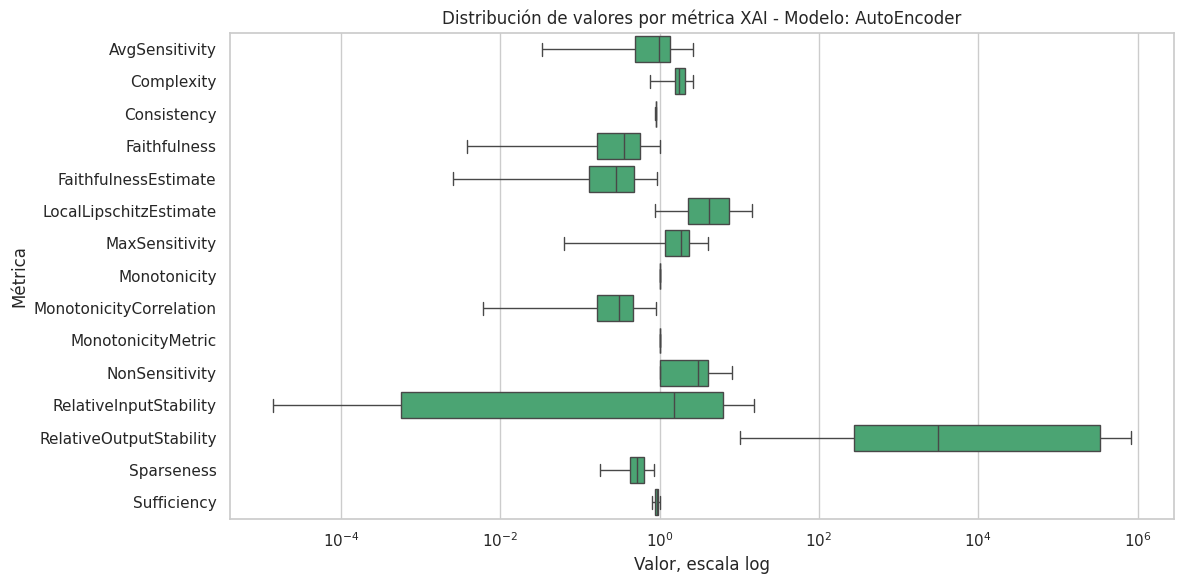

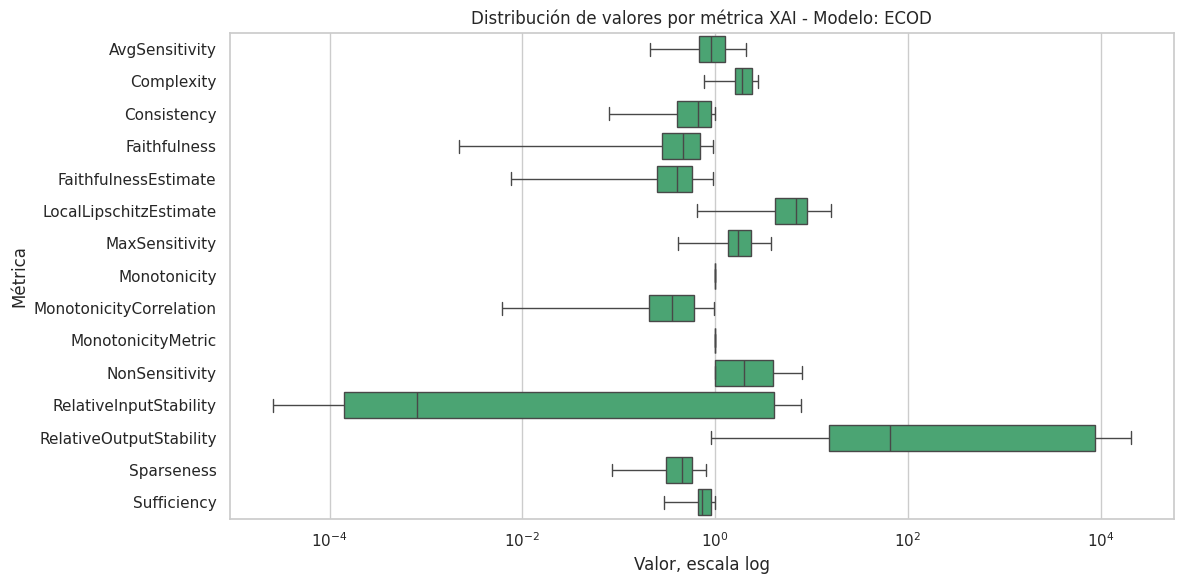

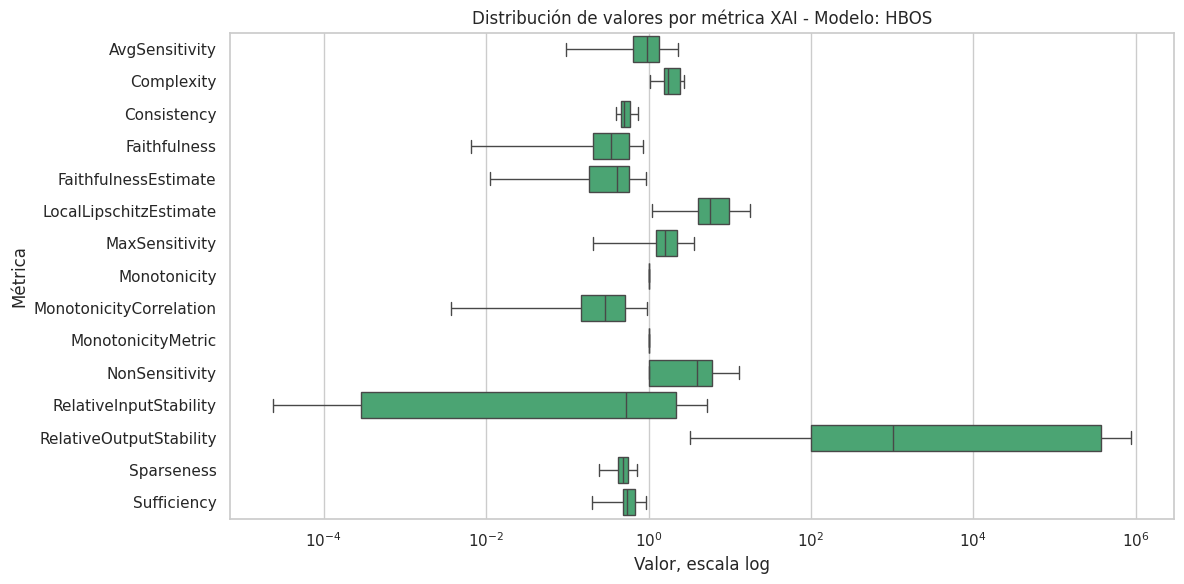

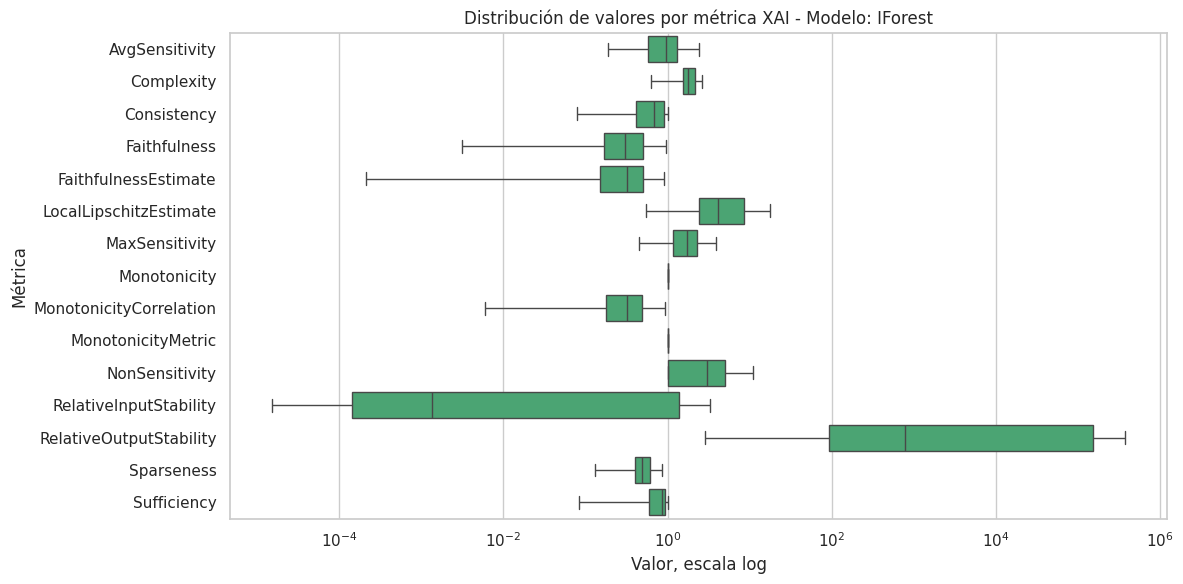

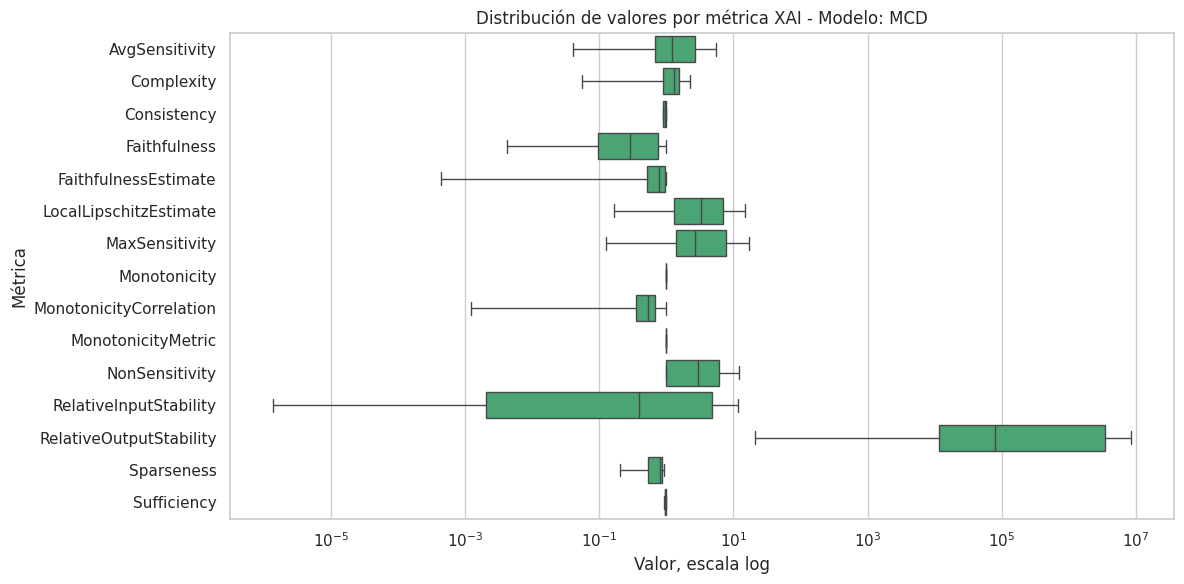

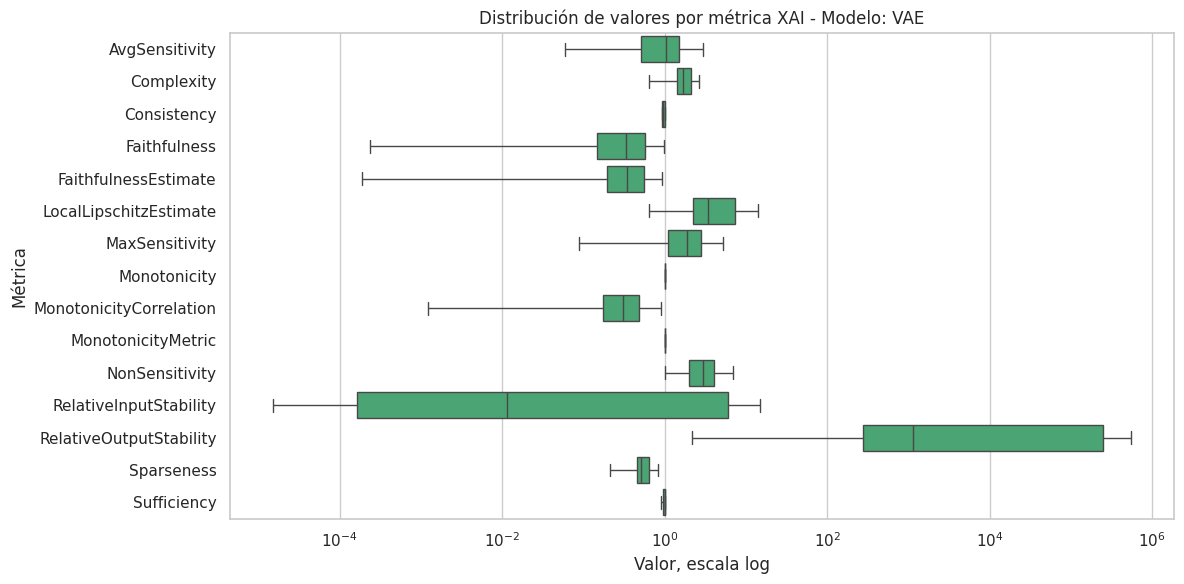

In [68]:
for model_name, model_df in plot_long_positive.groupby("model_name"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=model_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Modelo: {model_name}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()

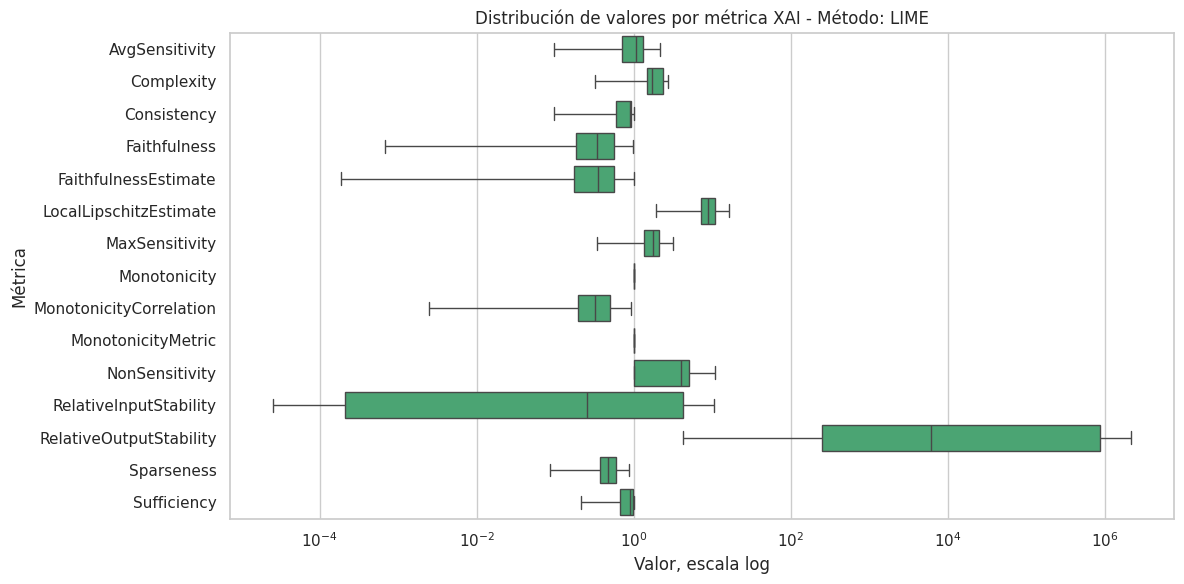

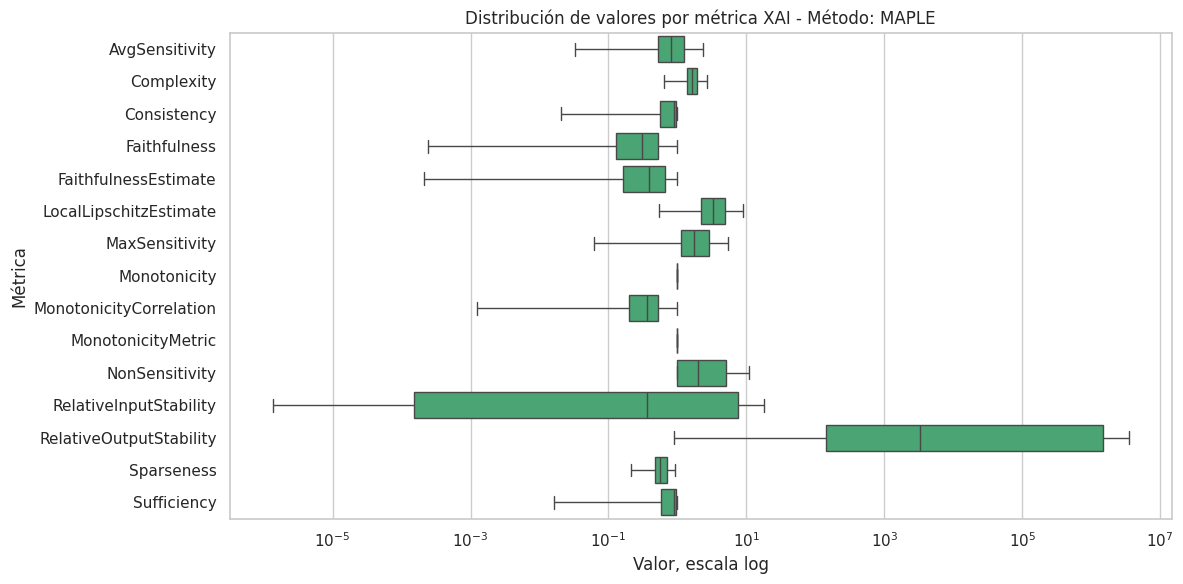

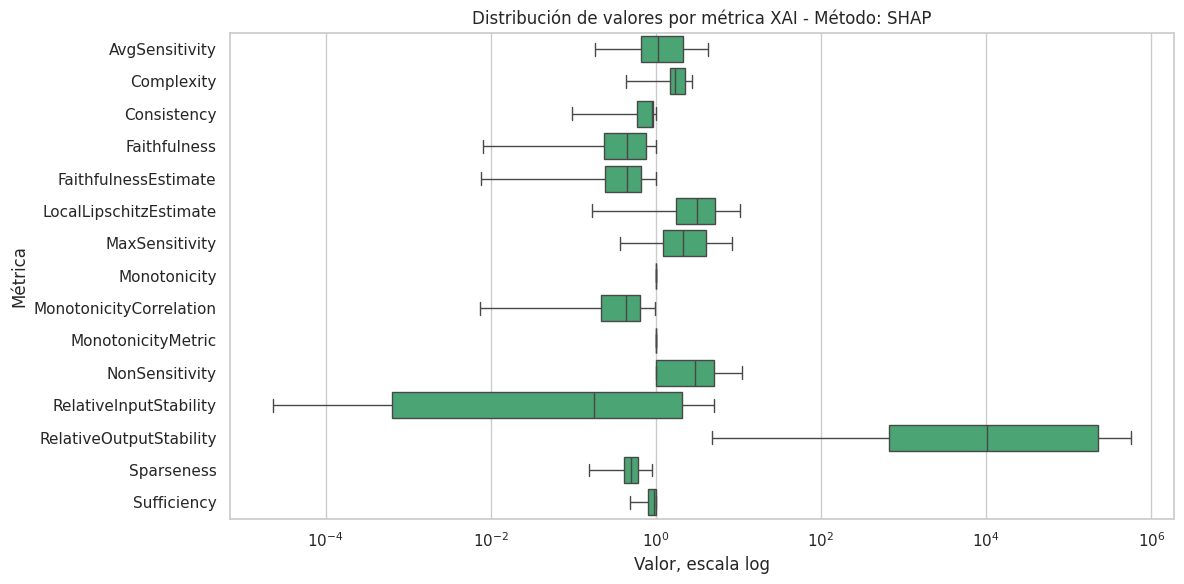

In [69]:
for xai_method, xai_df in plot_long_positive.groupby("xai_method"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=xai_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Método: {xai_method}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()

## Por dataset

In [70]:
dataset_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="dataset_name",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_dataset",
    remaining_factors=["model_name", "xai_method"],
    min_periods_corr=20,
    show_plots=False
)


===== dataset_name: AHU21 =====
Filas: 1260
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
                  metric_1                 metric_2  spearman_corr  \
25              Complexity               Sparseness      -0.996917   
5           AvgSensitivity           MaxSensitivity       0.814425   
99  RelativeInputStability  RelativeOutputStability       0.731893   

          p_value     n  abs_corr  significant_0.05  
25   0.000000e+00  1260  0.996917              True  
5   4.418754e-283  1190  0.814425              True  
99  2.140573e-124   736  0.731893              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
4,Consistency,model_name,897.220228,1.063461e-191,True
11,LocalLipschitzEstimate,xai_method,738.476792,4.383308e-161,True
26,Sparseness,model_name,615.391238,9.553264e-131,True
2,Complexity,model_name,603.621201,3.337673e-128,True
14,Monotonicity,model_name,525.034394,3.146368e-111,True
24,RelativeOutputStability,model_name,383.429548,1.104262e-80,True
28,Sufficiency,model_name,307.770925,2.136876e-64,True
29,Sufficiency,xai_method,272.302563,7.417368e-60,True
16,MonotonicityCorrelation,model_name,278.238753,4.757096e-58,True
3,Complexity,xai_method,202.260531,1.201390e-44,True



===== dataset_name: ARAMIS20 =====
Filas: 1260
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
          metric_1        metric_2  spearman_corr        p_value     n  \
25      Complexity      Sparseness      -0.994188   0.000000e+00  1260   
5   AvgSensitivity  MaxSensitivity       0.929057   0.000000e+00  1260   
79    Monotonicity  NonSensitivity       0.699771  5.492404e-186  1260   

    abs_corr  significant_0.05  
25  0.994188              True  
5   0.929057              True  
79  0.699771              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
14,Monotonicity,model_name,1259.000000,4.869849e-270,True
4,Consistency,model_name,682.755238,2.628495e-145,True
20,NonSensitivity,model_name,629.571349,8.237067e-134,True
11,LocalLipschitzEstimate,xai_method,429.003059,6.968982e-94,True
28,Sufficiency,model_name,385.060332,4.917026e-81,True
3,Complexity,xai_method,347.151349,4.140401e-76,True
27,Sparseness,xai_method,323.960296,4.496924e-71,True
24,RelativeOutputStability,model_name,161.855051,3.982492e-33,True
1,AvgSensitivity,xai_method,131.534649,2.739137e-29,True
10,LocalLipschitzEstimate,model_name,133.222675,4.925976e-27,True



===== dataset_name: MetroPT3 =====
Filas: 756
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:
          metric_1        metric_2  spearman_corr        p_value    n  \
25      Complexity      Sparseness      -0.994499   0.000000e+00  756   
5   AvgSensitivity  MaxSensitivity       0.896936  1.890882e-269  756   

    abs_corr  significant_0.05  
25  0.994499              True  
5   0.896936              True  
Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
14,Monotonicity,model_name,755.000000,6.270423e-161,True
4,Consistency,model_name,595.308343,2.087153e-126,True
29,Sufficiency,xai_method,547.034814,1.632674e-119,True
16,MonotonicityCorrelation,model_name,408.073864,5.395133e-86,True
26,Sparseness,model_name,331.417533,1.749462e-69,True
2,Complexity,model_name,320.032505,4.926053e-67,True
11,LocalLipschitzEstimate,xai_method,269.796104,2.597290e-59,True
21,NonSensitivity,xai_method,265.541442,2.179759e-58,True
20,NonSensitivity,model_name,269.019634,4.544201e-56,True
18,MonotonicityMetric,model_name,113.026333,9.390901e-23,True


In [71]:
variability_by_dataset = collect_variability(dataset_results, "dataset_name")
display(variability_by_dataset)

,dataset_name,metric,mean,std,range,missing_pct,n_unique
0,AHU21,RelativeOutputStability,5.773704e+08,1.004408e+10,2.667217e+11,41.428571,738
1,AHU21,MaxSensitivity,1.178087e+01,1.065044e+02,1.907456e+03,0.000000,1260
2,AHU21,AvgSensitivity,4.533084e+00,3.892139e+01,7.693539e+02,5.555556,1190
3,AHU21,LocalLipschitzEstimate,4.918257e+00,3.382075e+00,1.870432e+01,0.000000,1260
4,AHU21,NonSensitivity,5.653968e+00,2.791843e+00,1.400000e+01,0.000000,15
5,AHU21,RelativeInputStability,3.189461e-01,1.187588e+00,1.209483e+01,39.603175,761
6,AHU21,Complexity,2.053983e+00,5.746842e-01,2.641201e+00,0.000000,1252
7,AHU21,FaithfulnessEstimate,6.320206e-03,4.888001e-01,1.995796e+00,0.000000,1260
8,AHU21,Faithfulness,-1.416315e-01,4.804729e-01,1.987227e+00,0.000000,1259
9,AHU21,Sufficiency,5.306392e-01,4.180016e-01,1.000000e+00,0.000000,281


In [72]:
variability_by_dataset_summary = (
    variability_by_dataset
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("dataset_name", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_dataset_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,1.518136e+10,3.545119e+10,3.371678e+11,3
RelativeInputStability,2.848013e+03,4.790200e+03,4.766059e+04,3
MaxSensitivity,2.847847e+03,8.432331e+03,4.242887e+04,3
AvgSensitivity,2.019270e+03,6.016957e+03,3.059590e+04,3
LocalLipschitzEstimate,3.872466e+00,4.441848e+00,2.457563e+01,3
NonSensitivity,1.792509e+00,2.791843e+00,9.666667e+00,3
FaithfulnessEstimate,5.201690e-01,5.640328e-01,1.980007e+00,3
Faithfulness,4.926363e-01,5.462246e-01,1.981810e+00,3
Complexity,4.609744e-01,6.092752e-01,2.001358e+00,3


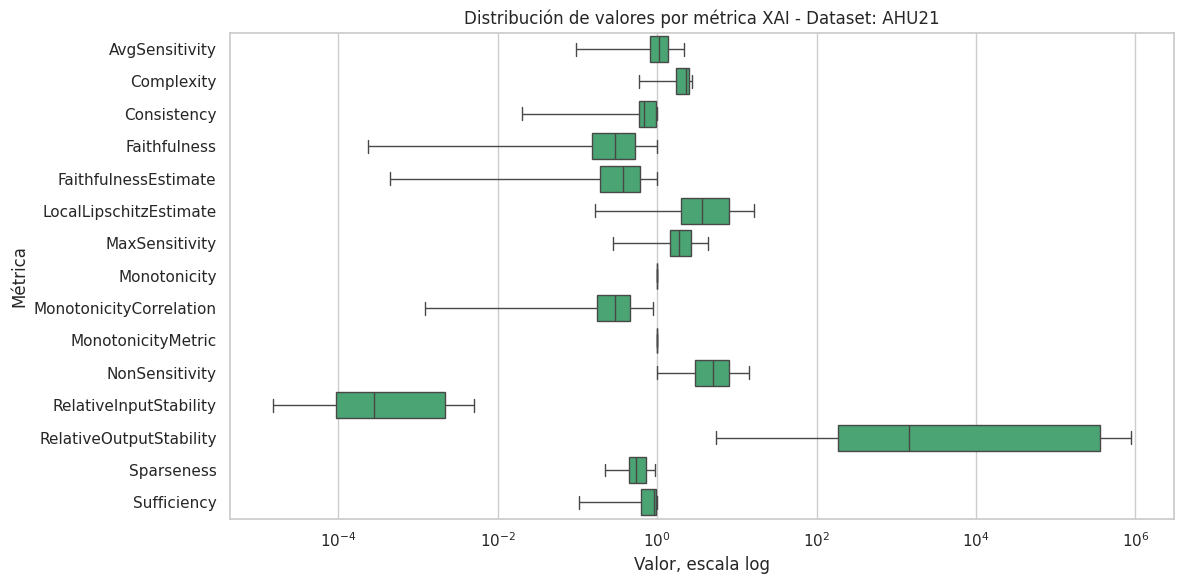

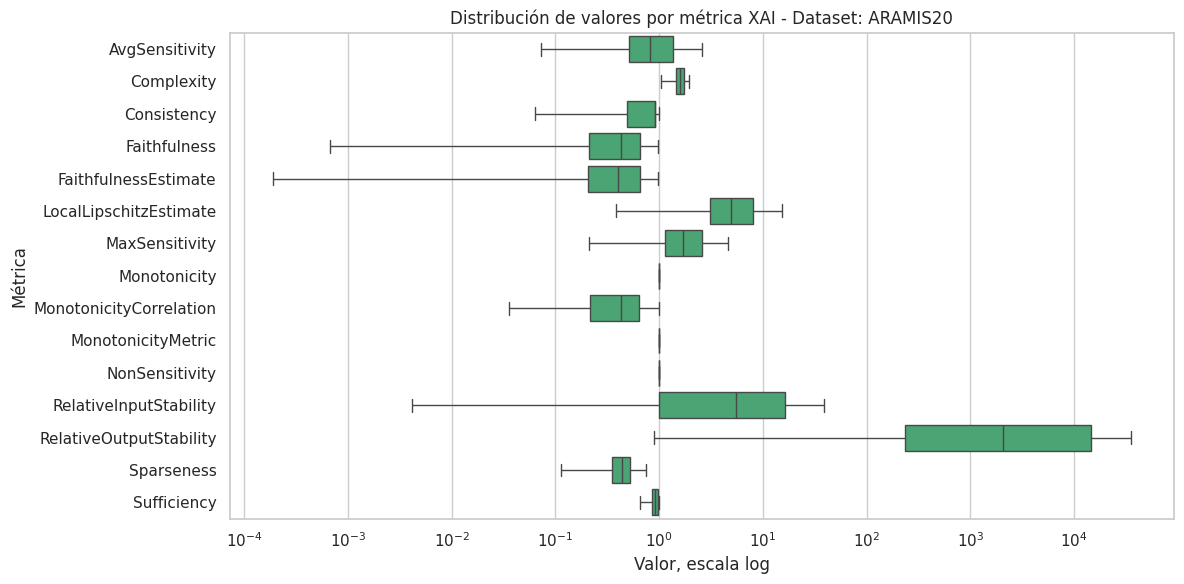

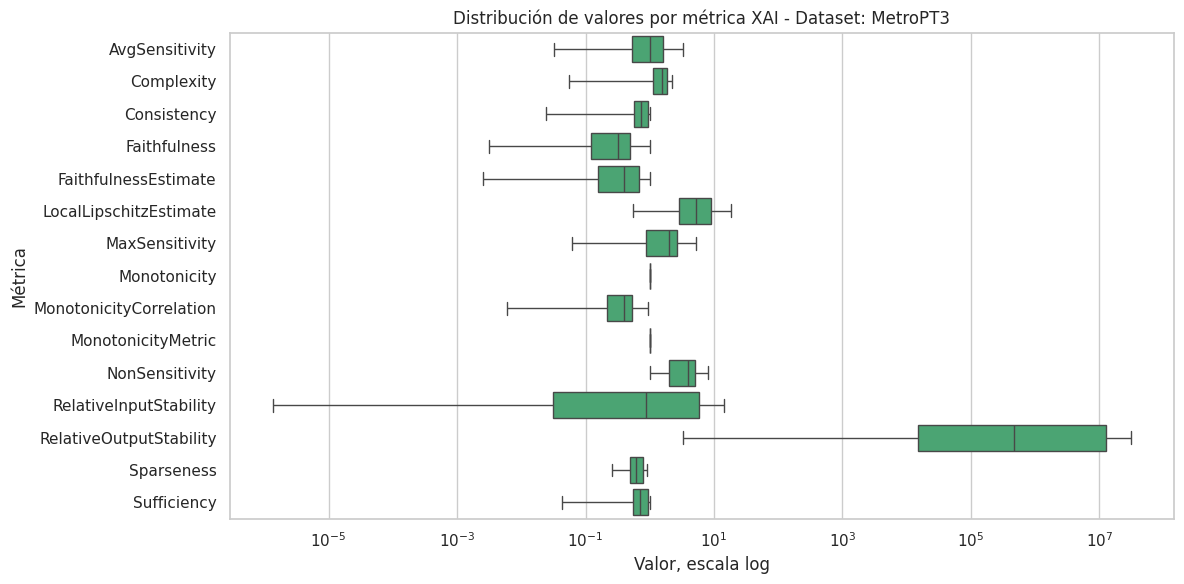

In [73]:
for dataset_name, dataset_df in plot_long_positive.groupby("dataset_name"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=dataset_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Dataset: {dataset_name}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()

# Ya no se ni lo que estoy haciendo

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(parents=True, exist_ok=True)

matrix_path = Path("results/metric_analysis_matrix.csv")
analysis_df = pd.read_csv(matrix_path)

id_cols = ["dataset_name", "model_name", "observation", "xai_method"]

metric_directions = {
    "Complexity": "lower",
    "Sparseness": "higher",
    "Faithfulness": "higher",
    "FaithfulnessEstimate": "higher",
    "LocalLipschitzEstimate": "lower",
    "AvgSensitivity": "lower",
    "MaxSensitivity": "lower",
    "RelativeInputStability": "lower",
    "RelativeOutputStability": "lower",
    "NonSensitivity": "lower",
    "Consistency": "lower",
    "Monotonicity": "higher",
    "MonotonicityCorrelation": "higher",
    "MonotonicityMetric": "higher",
    "Sufficiency": "higher",
    "SensitivityN": "higher",
    "Completeness": "higher"
}

metric_categories = {
    "Complexity": "Complexity",
    "Sparseness": "Complexity",
    "Faithfulness": "Faithfulness",
    "FaithfulnessEstimate": "Faithfulness",
    "LocalLipschitzEstimate": "Robustness",
    "AvgSensitivity": "Sensitivity",
    "MaxSensitivity": "Robustness",
    "RelativeInputStability": "Robustness",
    "RelativeOutputStability": "Robustness",
    "NonSensitivity": "Fidelity",
    "Consistency": "Faithfulness",
    "Monotonicity": "Faithfulness",
    "MonotonicityCorrelation": "Faithfulness",
    "MonotonicityMetric": "Faithfulness",
    "Sufficiency": "Faithfulness",
    "SensitivityN": "Faithfulness",
    "Completeness": "Fidelity"
}

metric_interpretations = {
    "Complexity": "explicaciones menos complejas",
    "Sparseness": "atribuciones más concentradas",
    "Faithfulness": "mayor fidelidad",
    "FaithfulnessEstimate": "mayor estimación de fidelidad",
    "LocalLipschitzEstimate": "mayor estabilidad local",
    "AvgSensitivity": "menor sensibilidad media",
    "MaxSensitivity": "menor sensibilidad máxima",
    "RelativeInputStability": "mayor estabilidad frente a cambios en la entrada",
    "RelativeOutputStability": "mayor estabilidad relativa en la salida",
    "NonSensitivity": "menor sensibilidad a características irrelevantes",
    "Consistency": "mayor consistencia",
    "Monotonicity": "mayor monotonicidad",
    "MonotonicityCorrelation": "mayor correlación monotónica",
    "MonotonicityMetric": "mayor cumplimiento de monotonicidad",
    "Sufficiency": "mayor suficiencia",
    "SensitivityN": "menor sensibilidad",
    "Completeness": "más completo"
}

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c in metric_directions
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

metric_cols

['AvgSensitivity',
 'Completeness',
 'Complexity',
 'Consistency',
 'Faithfulness',
 'FaithfulnessEstimate',
 'LocalLipschitzEstimate',
 'MaxSensitivity',
 'Monotonicity',
 'MonotonicityCorrelation',
 'MonotonicityMetric',
 'NonSensitivity',
 'RelativeInputStability',
 'RelativeOutputStability',
 'SensitivityN',
 'Sparseness',
 'Sufficiency']

In [75]:
method_summary = (
    analysis_df
    .groupby("xai_method")[metric_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

method_summary.to_csv(results_dir / "method_summary.csv")

method_summary

AvgSensitivity                                                 \
                     mean    median          std       min           max   
xai_method                                                                 
LIME             1.057664  1.060571     0.534806  0.095703      3.836830   
MAPLE          455.694401  0.820476  5014.273414  0.032754  90978.394793   
SHAP             1.534397  1.072866     1.359753  0.182380     18.778814   

           Completeness                            ... Sparseness            \
                   mean median  std    min    max  ...       mean    median   
xai_method                                         ...                        
LIME                0.0    0.0  0.0  False  False  ...   0.493969  0.465812   
MAPLE               0.0    0.0  0.0  False  False  ...   0.581819  0.559301   
SHAP                0.0    0.0  0.0  False  False  ...   0.528380  0.497860   

                                         Sufficiency                           \
                 std       min       max        mean    median       std  min   
xai_method                                                                      
LIME        0.190926  0.085967  0.879448    0.572492  0.722222  0.407418  0.0   
MAPLE       0.151264  0.209878  0.935374    0.476716  0.519984  0.419711  0.0   
SHAP        0.172388  0.130748  0.937304    0.563034  0.793662  0.441416  0.0   

                 
            max  
xai_method       
LIME        1.0  
MAPLE       1.0  
SHAP        1.0  

[3 rows x 85 columns]

In [76]:
analysis_long = analysis_df.melt(
    id_vars=["dataset_name", "model_name", "observation", "xai_method"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="value"
)

method_summary_long = (
    analysis_long
    .groupby(["xai_method", "metric"])
    .agg(
        mean=("value", "mean"),
        median=("value", "median"),
        std=("value", "std"),
        q1=("value", lambda x: x.quantile(0.25)),
        q3=("value", lambda x: x.quantile(0.75)),
        min=("value", "min"),
        max=("value", "max"),
        count=("value", "count"),
        missing=("value", lambda x: x.isna().sum()),
        total=("value", "size"),
    )
    .reset_index()
)

method_summary_long["iqr"] = method_summary_long["q3"] - method_summary_long["q1"]
method_summary_long["missing_pct"] = (
    method_summary_long["missing"] / method_summary_long["total"] * 100
)

method_summary_long["category"] = method_summary_long["metric"].map(metric_categories)
method_summary_long["direction"] = method_summary_long["metric"].map(metric_directions)
method_summary_long["interpretation"] = method_summary_long["metric"].map(metric_interpretations)

method_summary_long = method_summary_long[
    [
        "metric", "category", "direction", "xai_method",
        "mean", "median", "std", "iqr", "min", "max",
        "missing_pct", "interpretation"
    ]
].sort_values(["category", "metric", "xai_method"])

method_summary_long.to_csv(
    results_dir / "method_summary_long.csv",
    index=False
)

method_summary_long

/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,metric,category,direction,xai_method,mean,median,std,iqr,min,max,missing_pct,interpretation
2,Complexity,Complexity,lower,LIME,1.793907,1.70948,5.675750e-01,8.984588e-01,0.319121,2.754321,0.000000,explicaciones menos complejas
19,Complexity,Complexity,lower,MAPLE,1.614178,1.599622,5.006813e-01,5.444790e-01,-0.0,2.658188,0.000000,explicaciones menos complejas
36,Complexity,Complexity,lower,SHAP,1.723162,1.717777,5.803365e-01,7.251190e-01,0.055955,2.728393,0.000000,explicaciones menos complejas
15,Sparseness,Complexity,higher,LIME,0.493969,0.465812,1.909258e-01,2.325641e-01,0.085967,0.879448,0.000000,atribuciones más concentradas
32,Sparseness,Complexity,higher,MAPLE,0.581819,0.559301,1.512637e-01,2.248523e-01,0.209878,0.935374,0.000000,atribuciones más concentradas
49,Sparseness,Complexity,higher,SHAP,0.52838,0.49786,1.723884e-01,1.889130e-01,0.130748,0.937304,0.000000,atribuciones más concentradas
3,Consistency,Faithfulness,lower,LIME,0.743973,0.902439,2.580232e-01,3.333333e-01,0.015873,1.0,0.000000,mayor consistencia
20,Consistency,Faithfulness,lower,MAPLE,0.752274,0.904762,2.575320e-01,3.902439e-01,0.020408,1.0,0.000000,mayor consistencia
37,Consistency,Faithfulness,lower,SHAP,0.743973,0.902439,2.580232e-01,3.333333e-01,0.015873,1.0,0.000000,mayor consistencia
4,Faithfulness,Faithfulness,higher,LIME,-0.184612,-0.193086,5.034405e-01,8.298513e-01,-0.999663,0.987027,0.000000,mayor fidelidad


In [77]:
grouped_summary = (
    analysis_long
    .groupby(["dataset_name", "model_name", "xai_method", "metric"])
    .agg(
        mean=("value", "mean"),
        median=("value", "median"),
        std=("value", "std"),
        q1=("value", lambda x: x.quantile(0.25)),
        q3=("value", lambda x: x.quantile(0.75)),
        min=("value", "min"),
        max=("value", "max"),
        count=("value", "count"),
        missing=("value", lambda x: x.isna().sum()),
        total=("value", "size"),
    )
    .reset_index()
)

grouped_summary["iqr"] = grouped_summary["q3"] - grouped_summary["q1"]
grouped_summary["missing_pct"] = grouped_summary["missing"] / grouped_summary["total"] * 100
grouped_summary["category"] = grouped_summary["metric"].map(metric_categories)
grouped_summary["direction"] = grouped_summary["metric"].map(metric_directions)

grouped_summary.to_csv(
    results_dir / "grouped_dataset_model_xai_metric_summary.csv",
    index=False
)

grouped_summary

/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/usuario/Escritorio/XAI_metrics/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keep

,dataset_name,model_name,xai_method,metric,mean,median,std,q1,q3,min,max,count,missing,total,iqr,missing_pct,category,direction
0,AHU21,AutoEncoder,LIME,AvgSensitivity,1.13082,1.08684,1.713961e-01,1.017418,1.318878e+00,0.779654,1.44062,70,0,70,3.014593e-01,0.000000,Sensitivity,lower
1,AHU21,AutoEncoder,LIME,Completeness,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,70,0,70,0.000000e+00,0.000000,Fidelity,higher
2,AHU21,AutoEncoder,LIME,Complexity,2.344844,2.346426,2.717298e-02,2.324943,2.362771e+00,2.291695,2.406341,70,0,70,3.782875e-02,0.000000,Complexity,lower
3,AHU21,AutoEncoder,LIME,Consistency,0.819048,0.888889,2.450022e-01,0.888889,8.888889e-01,0.095238,1.0,70,0,70,0.000000e+00,0.000000,Faithfulness,lower
4,AHU21,AutoEncoder,LIME,Faithfulness,-0.043856,0.120666,3.983009e-01,-0.497056,3.094008e-01,-0.719233,0.497606,70,0,70,8.064571e-01,0.000000,Faithfulness,higher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,MetroPT3,VAE,SHAP,RelativeInputStability,337.99033,0.953514,8.850811e+02,0.401513,1.290816e+00,0.180083,3528.299119,36,6,42,8.893031e-01,14.285714,Robustness,lower
914,MetroPT3,VAE,SHAP,RelativeOutputStability,24656686.196627,1398402.41956,4.490366e+07,357581.422167,1.908644e+07,204952.26924,180381848.384123,36,6,42,1.872885e+07,14.285714,Robustness,lower
915,MetroPT3,VAE,SHAP,SensitivityN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,42,42,NaN,100.000000,Faithfulness,higher
916,MetroPT3,VAE,SHAP,Sparseness,0.642284,0.706612,1.529912e-01,0.471522,7.947874e-01,0.414054,0.822152,42,0,42,3.232658e-01,0.000000,Complexity,higher


In [78]:
grouped_median_matrix = (
    grouped_summary
    .pivot_table(
        index=["dataset_name", "model_name", "xai_method"],
        columns="metric",
        values="median"
    )
    .reset_index()
)

grouped_median_matrix.columns.name = None

grouped_median_matrix.to_csv(
    results_dir / "grouped_dataset_model_xai_median_matrix.csv",
    index=False
)

grouped_median_matrix

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.08684,0.0,2.346426,0.888889,0.120666,0.089934,7.652899,1.889464,1.0,0.354167,0.0,4.0,0.000075,232.39962,0.534343,0.9022
1,AHU21,AutoEncoder,MAPLE,0.647022,0.0,1.782449,0.87037,-0.029768,0.051885,3.272467,1.540276,1.0,0.135213,0.0,4.0,0.000892,2084.89322,0.707288,0.0
2,AHU21,AutoEncoder,SHAP,1.394124,0.0,2.305058,0.888889,-0.021374,0.054937,1.743821,2.81913,1.0,0.036765,0.0,4.0,0.000232,372.624479,0.545312,0.930195
3,AHU21,ECOD,LIME,1.149022,0.0,2.678848,0.666667,-0.696714,-0.153375,8.651761,1.588119,1.0,0.148284,0.0,4.0,0.0001,18.399774,0.30676,0.625
4,AHU21,ECOD,MAPLE,0.806187,0.0,1.957012,0.611111,0.190737,-0.002047,1.886993,1.476946,1.0,0.3125,0.0,5.0,0.000111,22.205558,0.647634,0.0
5,AHU21,ECOD,SHAP,NaN,0.0,2.442762,0.666667,-0.451511,-0.027726,7.365368,2.157145,1.0,-0.477941,0.0,4.0,0.000274,NaN,0.47625,0.702729
6,AHU21,HBOS,LIME,0.961764,0.0,2.507692,0.587302,-0.145318,-0.107651,9.605597,1.514265,1.0,0.012262,0.0,6.5,0.000107,191.881018,0.427862,0.47913
7,AHU21,HBOS,MAPLE,0.936158,0.0,2.501146,0.527273,0.019752,-0.069725,2.919522,1.625706,1.0,0.014711,0.0,6.0,0.000148,182.40199,0.433278,0.589744
8,AHU21,HBOS,SHAP,1.092321,0.0,2.335485,0.587302,-0.107673,-0.233784,4.883915,1.616672,1.0,-0.528257,0.0,5.5,1.075615,465492.720271,0.533321,0.0
9,AHU21,IForest,LIME,1.106137,0.0,2.511141,0.68254,-0.053643,-0.016006,9.540279,1.778655,1.0,0.254902,0.0,4.0,0.000175,111.112013,0.422341,0.612941


In [79]:
method_median_wide = (
    method_summary_long
    .pivot_table(
        index=["metric", "category", "direction", "interpretation"],
        columns="xai_method",
        values="median"
    )
    .reset_index()
)

method_cols = [
    c for c in method_median_wide.columns
    if c not in ["metric", "category", "direction", "interpretation"]
]

def best_method_from_row(row):
    values = row[method_cols].dropna()

    if values.empty:
        return np.nan

    if row["direction"] == "lower":
        return values.idxmin()

    return values.idxmax()

method_median_wide["best_method"] = method_median_wide.apply(
    best_method_from_row,
    axis=1
)

method_median_wide = method_median_wide.sort_values(["category", "metric"])

method_median_wide.to_csv(
    results_dir / "global_method_ranking_by_metric.csv",
    index=False
)

method_median_wide

xai_method,metric,category,direction,interpretation,LIME,MAPLE,SHAP,best_method
2,Complexity,Complexity,lower,explicaciones menos complejas,1.70948,1.599622,1.717777,MAPLE
14,Sparseness,Complexity,higher,atribuciones más concentradas,0.465812,0.559301,0.49786,MAPLE
3,Consistency,Faithfulness,lower,mayor consistencia,0.902439,0.904762,0.902439,LIME
4,Faithfulness,Faithfulness,higher,mayor fidelidad,-0.193086,0.025697,-0.286544,MAPLE
5,FaithfulnessEstimate,Faithfulness,higher,mayor estimación de fidelidad,-0.095443,0.027899,-0.071715,MAPLE
8,Monotonicity,Faithfulness,higher,mayor monotonicidad,1.0,1.0,1.0,LIME
9,MonotonicityCorrelation,Faithfulness,higher,mayor correlación monotónica,0.23123,0.251131,0.067749,MAPLE
10,MonotonicityMetric,Faithfulness,higher,mayor cumplimiento de monotonicidad,0.0,0.0,0.0,LIME
15,Sufficiency,Faithfulness,higher,mayor suficiencia,0.722222,0.519984,0.793662,SHAP
1,Completeness,Fidelity,higher,más completo,0.0,0.0,0.0,LIME


In [80]:
ranking_rows = []

for (dataset, model, metric), metric_df in grouped_summary.groupby(
    ["dataset_name", "model_name", "metric"]
):
    direction = metric_directions.get(metric)

    if direction is None:
        continue

    metric_df = metric_df.dropna(subset=["median"]).copy()

    if metric_df.empty:
        continue

    ascending = direction == "lower"

    metric_df["rank"] = metric_df["median"].rank(
        method="min",
        ascending=ascending
    )

    best_value = metric_df["median"].min() if ascending else metric_df["median"].max()
    best_methods = metric_df.loc[
        metric_df["median"] == best_value,
        "xai_method"
    ].tolist()

    for _, row in metric_df.iterrows():
        ranking_rows.append({
            "dataset_name": dataset,
            "model_name": model,
            "metric": metric,
            "category": metric_categories.get(metric),
            "direction": direction,
            "xai_method": row["xai_method"],
            "median": row["median"],
            "rank": row["rank"],
            "is_best": row["xai_method"] in best_methods,
            "best_methods": ", ".join(best_methods),
            "interpretation": metric_interpretations.get(metric),
        })

ranking_df = pd.DataFrame(ranking_rows)

ranking_df.to_csv(
    results_dir / "ranking_by_dataset_model_metric.csv",
    index=False
)

ranking_df

,dataset_name,model_name,metric,category,direction,xai_method,median,rank,is_best,best_methods,interpretation
0,AHU21,AutoEncoder,AvgSensitivity,Sensitivity,lower,LIME,1.086840,2.0,False,MAPLE,menor sensibilidad media
1,AHU21,AutoEncoder,AvgSensitivity,Sensitivity,lower,MAPLE,0.647022,1.0,True,MAPLE,menor sensibilidad media
2,AHU21,AutoEncoder,AvgSensitivity,Sensitivity,lower,SHAP,1.394124,3.0,False,MAPLE,menor sensibilidad media
3,AHU21,AutoEncoder,Completeness,Fidelity,higher,LIME,0.000000,1.0,True,"LIME, MAPLE, SHAP",más completo
4,AHU21,AutoEncoder,Completeness,Fidelity,higher,MAPLE,0.000000,1.0,True,"LIME, MAPLE, SHAP",más completo
...,...,...,...,...,...,...,...,...,...,...,...
857,MetroPT3,VAE,Sparseness,Complexity,higher,MAPLE,0.476814,3.0,False,LIME,atribuciones más concentradas
858,MetroPT3,VAE,Sparseness,Complexity,higher,SHAP,0.706612,2.0,False,LIME,atribuciones más concentradas
859,MetroPT3,VAE,Sufficiency,Faithfulness,higher,LIME,0.000000,2.0,False,MAPLE,mayor suficiencia
860,MetroPT3,VAE,Sufficiency,Faithfulness,higher,MAPLE,0.942017,1.0,True,MAPLE,mayor suficiencia


In [81]:
win_counts = (
    ranking_df[ranking_df["is_best"]]
    .groupby(["xai_method"])
    .size()
    .reset_index(name="n_best")
    .sort_values("n_best", ascending=False)
)

win_counts.to_csv(
    results_dir / "win_counts_by_method.csv",
    index=False
)

win_counts

,xai_method,n_best
1,MAPLE,185
2,SHAP,135
0,LIME,124


In [82]:
win_counts_by_category = (
    ranking_df[ranking_df["is_best"]]
    .groupby(["category", "xai_method"])
    .size()
    .reset_index(name="n_best")
    .sort_values(["category", "n_best"], ascending=[True, False])
)

win_counts_by_category.to_csv(
    results_dir / "win_counts_by_category_method.csv",
    index=False
)

win_counts_by_category

,category,xai_method,n_best
1,Complexity,MAPLE,22
0,Complexity,LIME,10
2,Complexity,SHAP,4
4,Faithfulness,MAPLE,94
5,Faithfulness,SHAP,70
3,Faithfulness,LIME,63
7,Fidelity,MAPLE,33
6,Fidelity,LIME,29
8,Fidelity,SHAP,29
11,Robustness,SHAP,28


In [83]:
method_variability = method_summary_long[
    [
        "metric", "category", "direction", "xai_method",
        "median", "std", "iqr", "missing_pct"
    ]
].copy()

method_variability = method_variability.sort_values(
    ["category", "metric", "iqr"]
)

method_variability.to_csv(
    results_dir / "method_variability_by_metric.csv",
    index=False
)

method_variability

,metric,category,direction,xai_method,median,std,iqr,missing_pct
19,Complexity,Complexity,lower,MAPLE,1.599622,5.006813e-01,5.444790e-01,0.000000
36,Complexity,Complexity,lower,SHAP,1.717777,5.803365e-01,7.251190e-01,0.000000
2,Complexity,Complexity,lower,LIME,1.70948,5.675750e-01,8.984588e-01,0.000000
49,Sparseness,Complexity,higher,SHAP,0.49786,1.723884e-01,1.889130e-01,0.000000
32,Sparseness,Complexity,higher,MAPLE,0.559301,1.512637e-01,2.248523e-01,0.000000
15,Sparseness,Complexity,higher,LIME,0.465812,1.909258e-01,2.325641e-01,0.000000
3,Consistency,Faithfulness,lower,LIME,0.902439,2.580232e-01,3.333333e-01,0.000000
37,Consistency,Faithfulness,lower,SHAP,0.902439,2.580232e-01,3.333333e-01,0.000000
20,Consistency,Faithfulness,lower,MAPLE,0.904762,2.575320e-01,3.902439e-01,0.000000
21,Faithfulness,Faithfulness,higher,MAPLE,0.025697,3.992005e-01,5.168794e-01,0.000000


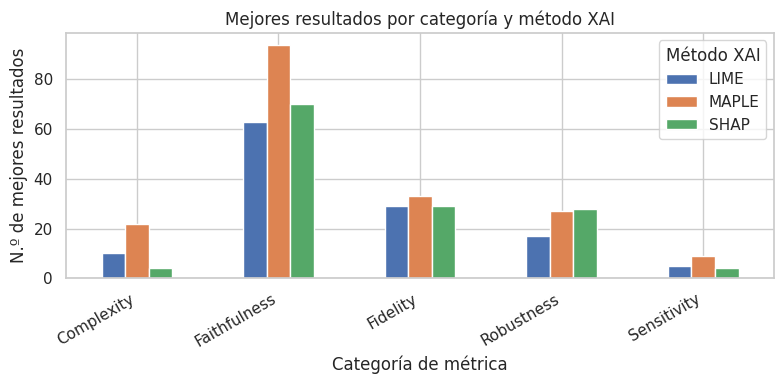

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Cargar resultados
df = pd.read_csv("results/conclusions_obs_results/win_counts_by_category_method.csv")

# Pasar a formato matriz
plot_df = df.pivot(
    index="category",
    columns="xai_method",
    values="n_best"
).fillna(0)

# Orden deseado de categorías
category_order = [
    "Complexity",
    "Faithfulness",
    "Fidelity",
    "Robustness",
    "Sensitivity"
]

plot_df = plot_df.loc[category_order]

# Crear gráfica
ax = plot_df.plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_xlabel("Categoría de métrica")
ax.set_ylabel("N.º de mejores resultados")
ax.set_title("Mejores resultados por categoría y método XAI")
ax.legend(title="Método XAI")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
plt.savefig(
    "figures/mejores_resultados_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()